# XAUUSD Momentum Pipeline

Rules-based momentum backtest (no ML). Follows `STRATEGY_DEVELOPMENT_PIPELINE.md`.

Alur: data → validasi → indikator → plugin strategy → backtest → walk-forward → robustness → Monte Carlo → **preview strategy** → export spec MQL5.

Notebook ML lama: `archive/BackTestXau_ML.ipynb`.


## 1. Configuration

`ACTIVE_STRATEGY` bisa satu nama, list nama, atau `"*"` (semua plugin terdaftar). Screening IS/OOS selalu dijalankan untuk seluruh queue. Set `MULTI_DEEP = True` jika ingin walk-forward, robustness, Monte Carlo, dan export per strategy.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

SYMBOL = "XAUUSD"
TIMEFRAME = "1H"
DATA_PATH = Path("XAUUSD_2009_2026_M1.csv")
EXPORT_DIR = Path("exports")
SOURCE_NOTEBOOK = "XAUUSD_Momentum_Pipeline.ipynb"

INITIAL_EQUITY = 10_000.0
FEE = 0.0                 # % notional per side (gold usually commission, not 0.1%)
COMMISSION_PER_LOT = 7.0  # USD round-turn per 1.00 lot (typical XAU ECN)
SPREAD = 0.25             # absolute price (bid/ask)
SLIPPAGE = 0.0001         # 0.01% of price per fill
RISK_PCT = 0.01           # 1% equity per trade
CONTRACT_SIZE = 100       # MT5 XAUUSD typical
MAX_POSITIONS = 1

# str | list[str] | "*"  ("*" = semua plugin yang terdaftar)
# Contoh multi:
#   ACTIVE_STRATEGY = "*"
#   ACTIVE_STRATEGY = ["momentum_squeeze_by_kimi", "trend_breakout_by_gemini"]
ACTIVE_STRATEGY = "*"
# True = WF + robustness + MC + preview + export untuk SETIAP strategy (lambat)
MULTI_DEEP = True
PARAMS = {
    "ema_fast": 20,
    "ema_slow": 50,
    "ema_trend": 200,
    "lookback": 24,
    "rsi_period": 14,
    "rsi_threshold": 50,
    "rsi_th": 50.0,
    "rsi_long": 52.0,
    "rsi_short": 48.0,
    "adx_th": 20.0,
    "adx_min": 20.0,
    "adx_rise": 3,
    "volume_ma": 20,
    "atr_period": 14,
    "atr_sl": 2.0,
    "atr_tp": 4.0,
    "atr_sl_gemini": 2.0,
    "atr_tp_gemini": 4.0,
    "atr_sl_claude": 2.0,
    "atr_tp_claude": 4.0,
    "atr_sl_kimi": 2.0,
    "atr_tp_kimi": 4.0,
    "allow_short": True,
    "use_volume_filter": True,
}

IN_SAMPLE_END = "2023-12-31"
OOS_START = "2024-01-01"

N_MC_SIMS = 10_000
MC_SEED = 42
VOLUME_DEAD_THRESHOLD = 0.80

EMA_PERIODS = [10, 15, 18, 19, 20, 21, 22, 25, 30, 48, 49, 50, 51, 52, 200]

_strat_label = ACTIVE_STRATEGY if isinstance(ACTIVE_STRATEGY, str) else ", ".join(ACTIVE_STRATEGY)
print(f"{SYMBOL} {TIMEFRAME} | strategy={_strat_label} | cap={INITIAL_EQUITY:,.0f}")
print(f"fee={FEE:.4%}  commission/lot={COMMISSION_PER_LOT}  spread={SPREAD}  slippage={SLIPPAGE:.4%}  risk={RISK_PCT:.2%}")
print(f"MULTI_DEEP={MULTI_DEEP}  (screening IS/OOS selalu; deep pipeline hanya jika 1 strategy atau MULTI_DEEP=True)")


XAUUSD 1H | strategy=* | cap=10,000
fee=0.0000%  commission/lot=7.0  spread=0.25  slippage=0.0100%  risk=1.00%
MULTI_DEEP=True  (screening IS/OOS selalu; deep pipeline hanya jika 1 strategy atau MULTI_DEEP=True)


## 2. Data

Load M1 CSV, validate OHLCV, resample to H1. Weekend gaps are expected for gold.


In [2]:
def load_raw(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    rename = {c: c.title() for c in df.columns}
    df = df.rename(columns=rename)
    if "Datetime" not in df.columns:
        raise ValueError(f"Datetime column missing: {list(df.columns)}")
    df["Datetime"] = pd.to_datetime(df["Datetime"], utc=False)
    df = df.sort_values("Datetime")
    return df.reset_index(drop=True)


def validate_ohlcv(df: pd.DataFrame, name: str, freq: str | None = None) -> dict:
    report = {"name": name, "rows": int(len(df))}
    report["duplicate_ts"] = int(df["Datetime"].duplicated().sum()) if "Datetime" in df.columns else int(df.index.duplicated().sum())
    ts = df["Datetime"] if "Datetime" in df.columns else pd.Series(df.index)
    report["start"] = str(ts.min())
    report["end"] = str(ts.max())
    report["tz"] = str(getattr(ts.dt, "tz", None) or "naive (assume broker server time)")

    o, h, l, c = df["Open"], df["High"], df["Low"], df["Close"]
    invalid = (h < l) | (c > h) | (c < l) | (o > h) | (o < l) | ~np.isfinite(c)
    report["ohlc_invalid"] = int(invalid.sum())
    report["volume_zero_pct"] = float((df["Volume"] <= 0).mean())
    report["volume_dead"] = report["volume_zero_pct"] >= VOLUME_DEAD_THRESHOLD

    if freq:
        expected = pd.date_range(ts.min(), ts.max(), freq=freq)
        report["expected_bars"] = int(len(expected))
        report["missing_bars"] = int(len(expected.difference(pd.DatetimeIndex(ts))))
    else:
        report["missing_bars"] = None

    ret = c.pct_change().abs()
    report["gap_gt_2pct"] = int((ret > 0.02).sum())
    report["max_abs_return"] = float(ret.max()) if len(ret) else 0.0
    return report


def resample_h1(df: pd.DataFrame) -> pd.DataFrame:
    x = df.set_index("Datetime")
    h1 = x.resample("1h").agg(
        {
            "Open": "first",
            "High": "max",
            "Low": "min",
            "Close": "last",
            "Volume": "sum",
        }
    )
    h1 = h1.dropna(subset=["Open", "High", "Low", "Close"])
    h1 = h1.reset_index()
    return h1


raw = load_raw(DATA_PATH)
raw_report = validate_ohlcv(raw, "M1")
print("M1 validation:", raw_report)

if raw_report["duplicate_ts"]:
    raw = raw.drop_duplicates("Datetime", keep="first")
invalid_mask = (
    (raw["High"] < raw["Low"])
    | (raw["Close"] > raw["High"])
    | (raw["Close"] < raw["Low"])
    | (raw["Open"] > raw["High"])
    | (raw["Open"] < raw["Low"])
)
if invalid_mask.any():
    print(f"Dropping {int(invalid_mask.sum())} invalid M1 bars")
    raw = raw.loc[~invalid_mask].copy()

df = resample_h1(raw)
del raw
h1_report = validate_ohlcv(df, "H1", freq="1h")
VOLUME_USABLE = not h1_report["volume_dead"]
print("H1 validation:", h1_report)
print(f"VOLUME_USABLE={VOLUME_USABLE}  H1 rows={len(df):,}")
df.head()


M1 validation: {'name': 'M1', 'rows': 5889220, 'duplicate_ts': 420, 'start': '2009-03-15 17:00:00', 'end': '2026-01-09 16:58:00', 'tz': 'naive (assume broker server time)', 'ohlc_invalid': 0, 'volume_zero_pct': 1.0, 'volume_dead': True, 'missing_bars': None, 'gap_gt_2pct': 4, 'max_abs_return': 0.026498317557889006}
H1 validation: {'name': 'H1', 'rows': 100083, 'duplicate_ts': 0, 'start': '2009-03-15 17:00:00', 'end': '2026-01-09 16:00:00', 'tz': 'naive (assume broker server time)', 'ohlc_invalid': 0, 'volume_zero_pct': 1.0, 'volume_dead': True, 'expected_bars': 147456, 'missing_bars': 47373, 'gap_gt_2pct': 25, 'max_abs_return': 0.04588191774728689}
VOLUME_USABLE=False  H1 rows=100,083


,Datetime,Open,High,Low,Close,Volume
0,2009-03-15 17:00:00,929.60,929.60,929.60,929.60,0
1,2009-03-15 18:00:00,925.85,928.10,925.35,925.90,0
2,2009-03-15 19:00:00,926.10,927.05,924.55,926.35,0
3,2009-03-15 20:00:00,926.35,928.40,923.35,928.33,0
4,2009-03-15 21:00:00,928.40,928.80,926.03,926.35,0


## 3. Indicators

Technical indicators only. No labels, no `shift(-1)`, no ML targets.


In [3]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))


def true_range(df: pd.DataFrame) -> pd.Series:
    prev_close = df["Close"].shift(1)
    return pd.concat(
        [
            df["High"] - df["Low"],
            (df["High"] - prev_close).abs(),
            (df["Low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)


def atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    return true_range(df).ewm(alpha=1 / period, min_periods=period, adjust=False).mean()


def adx(df: pd.DataFrame, period: int = 14) -> pd.Series:
    up = df["High"].diff()
    down = -df["Low"].diff()
    plus_dm = pd.Series(np.where((up > down) & (up > 0), up, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down > up) & (down > 0), down, 0.0), index=df.index)
    atr_ = atr(df, period)
    plus_di = 100.0 * plus_dm.ewm(alpha=1 / period, min_periods=period, adjust=False).mean() / atr_
    minus_di = 100.0 * minus_dm.ewm(alpha=1 / period, min_periods=period, adjust=False).mean() / atr_
    dx = 100.0 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0.0, np.nan)
    return dx.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()


def add_indicators(df: pd.DataFrame, ema_periods: list[int] | None = None) -> pd.DataFrame:
    out = df.copy()
    periods = ema_periods or EMA_PERIODS
    for p in periods:
        out[f"ema_{p}"] = out["Close"].ewm(span=p, adjust=False).mean()
    out["rsi_14"] = rsi(out["Close"], 14)
    out["atr_14"] = atr(out, 14)
    out["ATR"] = out["atr_14"]
    out["adx_14"] = adx(out, 14)
    out["volume_ma_20"] = out["Volume"].rolling(20, min_periods=20).mean()
    out["range"] = out["High"] - out["Low"]
    return out


df_ind = add_indicators(df)
print(df_ind[["Datetime", "Close", "ema_20", "ema_50", "rsi_14", "atr_14", "adx_14", "volume_ma_20"]].tail())
print("NaN after warmup:", int(df_ind[["ema_200", "rsi_14", "atr_14", "adx_14"]].isna().any(axis=1).sum()))


                  Datetime     Close       ema_20       ema_50     rsi_14     atr_14     adx_14  volume_ma_20
100078 2026-01-09 12:00:00  4484.205  4477.078370  4464.162621  55.282133  16.437449  14.491938           0.0
100079 2026-01-09 13:00:00  4495.755  4478.857096  4465.401538  59.599481  16.809774  14.072668           0.0
100080 2026-01-09 14:00:00  4498.925  4480.768325  4466.716183  60.720377  16.257147  13.683346           0.0
100081 2026-01-09 15:00:00  4507.275  4483.292771  4468.306725  63.586242  15.981637  13.948563           0.0
100082 2026-01-09 16:00:00  4508.748  4485.717078  4469.892658  64.084066  15.286520  14.281176           0.0
NaN after warmup: 26


## 4. Strategy plugin

Copot-pasang: tulis `def nama_strategy` + `@register_strategy`. Backtester tidak diubah.

Kontrak output: `signal` (1 / -1 / 0), `sl_atr`, `tp_atr`.


In [4]:
STRATEGY_REGISTRY: dict[str, Callable] = {}
STRATEGY_SPECS: dict[str, str] = {}


def register_strategy(fn: Callable) -> Callable:
    STRATEGY_REGISTRY[fn.__name__] = fn
    STRATEGY_SPECS[fn.__name__] = (fn.__doc__ or "").strip()
    return fn


def list_strategies() -> list[str]:
    return sorted(STRATEGY_REGISTRY)


def get_strategy(name: str) -> Callable:
    if name not in STRATEGY_REGISTRY:
        available = ", ".join(list_strategies()) or "(kosong)"
        raise KeyError(f"Strategy '{name}' tidak ditemukan. Tersedia: {available}")
    return STRATEGY_REGISTRY[name]


def resolve_strategy_queue(spec) -> list[str]:
    if isinstance(spec, str) and spec in {"*", "all"}:
        names = list_strategies()
        if not names:
            raise KeyError("Tidak ada strategy terdaftar.")
        return names
    names = [spec] if isinstance(spec, str) else list(spec)
    missing = [n for n in names if n not in STRATEGY_REGISTRY]
    if missing:
        available = ", ".join(list_strategies()) or "(kosong)"
        raise KeyError(f"Strategy tidak ditemukan: {missing}. Tersedia: {available}")
    return names


def _ensure_ema(df: pd.DataFrame, period: int) -> pd.DataFrame:
    col = f"ema_{period}"
    if col not in df.columns:
        df = df.copy()
        df[col] = df["Close"].ewm(span=period, adjust=False).mean()
    return df


@register_strategy
def ema_rsi_volume(df: pd.DataFrame, params: dict | None = None) -> pd.DataFrame:
    '''LONG jika EMA_fast > EMA_slow AND RSI > threshold AND Volume > Volume_MA.
    Jika data volume mati (hampir semua 0), filter volume diabaikan.
    SHORT tidak dipakai.
    Exit: SL = sl_atr * ATR, TP = tp_atr * ATR.
    Execution: next bar open, sinyal pada candle yang sudah close.
    '''
    p = dict(PARAMS if params is None else {**PARAMS, **params})
    ema_fast = int(p.get("ema_fast", 20))
    ema_slow = int(p.get("ema_slow", 50))
    rsi_th = float(p.get("rsi_threshold", 50))
    vol_ma = int(p.get("volume_ma", 20))
    use_vol = bool(p.get("use_volume_filter", True)) and VOLUME_USABLE
    out = _ensure_ema(df, ema_fast)
    out = _ensure_ema(out, ema_slow)
    vol_col = f"volume_ma_{vol_ma}"
    if vol_col not in out.columns:
        out = out.copy()
        out[vol_col] = out["Volume"].rolling(vol_ma, min_periods=vol_ma).mean()

    long_cond = (out[f"ema_{ema_fast}"] > out[f"ema_{ema_slow}"]) & (out["rsi_14"] > rsi_th)
    if use_vol:
        long_cond = long_cond & (out["Volume"] > out[vol_col])

    out = out.copy()
    out["signal"] = 0
    out.loc[long_cond, "signal"] = 1
    out["sl_atr"] = float(p.get("atr_sl", 1.5))
    out["tp_atr"] = float(p.get("atr_tp", 3.0))
    out.attrs["volume_filter_applied"] = use_vol
    out.attrs["logic_spec"] = STRATEGY_SPECS["ema_rsi_volume"]
    return out


@register_strategy
def breakout_atr(df: pd.DataFrame, params: dict | None = None) -> pd.DataFrame:
    '''LONG jika Close menembus High rolling lookback (shift 1, tanpa look-ahead).
    SHORT tidak dipakai.
    Exit: SL = sl_atr * ATR, TP = tp_atr * ATR.
    Execution: next bar open.
    '''
    p = dict(PARAMS if params is None else {**PARAMS, **params})
    lookback = int(p.get("lookback", 20))
    out = df.copy()
    rolling_high = out["High"].rolling(lookback, min_periods=lookback).max().shift(1)
    out["signal"] = 0
    out.loc[out["Close"] > rolling_high, "signal"] = 1
    out["sl_atr"] = float(p.get("atr_sl", 1.5))
    out["tp_atr"] = float(p.get("atr_tp", 3.0))
    out.attrs["logic_spec"] = STRATEGY_SPECS["breakout_atr"]
    return out


@register_strategy
def trend_pullback_by_claude(df: pd.DataFrame, params: dict | None = None) -> pd.DataFrame:
    '''Trend-pullback momentum (by Claude).
    Regime : Close > EMA200 AND EMA200 naik (vs 5 bar lalu) -> hanya ikut uptrend besar.
    Kualitas: ADX > adx_min (trend nyata, bukan ranging) AND EMA_fast > EMA_slow.
    Trigger : pullback -- Low menyentuh/di bawah EMA_fast dalam pull_bars bar terakhir,
              lalu Close kembali di atas EMA_fast dan RSI > 50 (momentum resume).
    SHORT tidak dipakai.
    Exit    : SL = sl_atr * ATR (2.0), TP = tp_atr * ATR (4.0) -> minimal 2R.
    Execution: next bar open, sinyal pada candle yang sudah close.
    '''
    p = dict(PARAMS if params is None else {**PARAMS, **params})
    ema_fast = int(p.get("ema_fast", 20))
    ema_slow = int(p.get("ema_slow", 50))
    adx_min = float(p.get("adx_min", 20.0))
    pull_bars = int(p.get("pull_bars", 3))
    slope_bars = int(p.get("slope_bars", 5))

    out = _ensure_ema(df, ema_fast)
    out = _ensure_ema(out, ema_slow)
    out = _ensure_ema(out, 200)
    out = out.copy()

    regime = (out["Close"] > out["ema_200"]) & (out["ema_200"] > out["ema_200"].shift(slope_bars))
    quality = (out["adx_14"] > adx_min) & (out[f"ema_{ema_fast}"] > out[f"ema_{ema_slow}"])
    pulled_back = (out["Low"] <= out[f"ema_{ema_fast}"]).rolling(pull_bars, min_periods=1).max().astype(bool)
    resume = (out["Close"] > out[f"ema_{ema_fast}"]) & (out["rsi_14"] > 50)

    out["signal"] = 0
    out.loc[regime & quality & pulled_back & resume, "signal"] = 1
    out["sl_atr"] = float(p.get("atr_sl_claude", 2.0))
    out["tp_atr"] = float(p.get("atr_tp_claude", 4.0))
    out.attrs["logic_spec"] = STRATEGY_SPECS["trend_pullback_by_claude"]
    return out


@register_strategy
def trend_breakout_by_gemini(df: pd.DataFrame, params: dict | None = None) -> pd.DataFrame:
    '''Trend Momentum Donchian Breakout (by Gemini).
    1. Macro Regime   : Close > EMA200 (Long) / Close < EMA200 (Short).
    2. Trend Alignment: EMA_fast > EMA_slow (Long) / EMA_fast < EMA_slow (Short).
    3. Volatility/ADX : ADX > adx_th (20) — skip ranging / choppy market.
    4. Momentum RSI   : RSI > rsi_th (50) Long / RSI < (100 - rsi_th) Short.
    5. Trigger        : Donchian lookback High/Low breakout (shift 1, no look-ahead).
    6. Exit           : SL = 2.0 * ATR, TP = 4.0 * ATR (1:2 R:R).
    Execution         : next bar open, sinyal pada candle yang sudah close.
    '''
    p = dict(PARAMS if params is None else {**PARAMS, **params})
    ema_fast = int(p.get("ema_fast", 20))
    ema_slow = int(p.get("ema_slow", 50))
    ema_trend = int(p.get("ema_trend", 200))
    lookback = int(p.get("lookback", 24))
    adx_th = float(p.get("adx_th", 20.0))
    rsi_th = float(p.get("rsi_th", p.get("rsi_threshold", 50.0)))
    sl_atr = float(p.get("atr_sl_gemini", p.get("atr_sl", 2.0)))
    tp_atr = float(p.get("atr_tp_gemini", p.get("atr_tp", 4.0)))
    allow_short = bool(p.get("allow_short", True))

    out = _ensure_ema(df, ema_fast)
    out = _ensure_ema(out, ema_slow)
    out = _ensure_ema(out, ema_trend)
    out = out.copy()

    upper = out["High"].rolling(lookback, min_periods=lookback).max().shift(1)
    lower = out["Low"].rolling(lookback, min_periods=lookback).min().shift(1)
    adx_ok = out["adx_14"] > adx_th

    long_cond = (
        (out["Close"] > upper)
        & (out["Close"] > out[f"ema_{ema_trend}"])
        & (out[f"ema_{ema_fast}"] > out[f"ema_{ema_slow}"])
        & adx_ok
        & (out["rsi_14"] > rsi_th)
    )
    out["signal"] = 0
    out.loc[long_cond, "signal"] = 1

    if allow_short:
        short_cond = (
            (out["Close"] < lower)
            & (out["Close"] < out[f"ema_{ema_trend}"])
            & (out[f"ema_{ema_fast}"] < out[f"ema_{ema_slow}"])
            & adx_ok
            & (out["rsi_14"] < (100.0 - rsi_th))
        )
        out.loc[short_cond, "signal"] = -1

    out["sl_atr"] = sl_atr
    out["tp_atr"] = tp_atr
    out.attrs["logic_spec"] = STRATEGY_SPECS["trend_breakout_by_gemini"]
    return out


# buat strategi terbaik Versi mu jangan lupa beri mark model , _by_{model} , Tulis di bawa sini

@register_strategy
def momentum_squeeze_by_kimi(df: pd.DataFrame, params: dict | None = None) -> pd.DataFrame:
    '''Momentum Squeeze Breakout (by Kimi).
    1. Regime       : Close vs EMA200 + EMA_fast vs EMA_slow (arah tren).
    2. Volatility   : ADX > adx_th AND ADX rising (adx_14 > adx_14.shift(adx_rise)).
    3. Compression  : Donchian width / ATR < rolling median 100 (squeeze).
    4. Trigger      : Close menembus Donchian High/Low setelah squeeze (shift 1).
    5. Momentum     : RSI > rsi_long (52) Long / RSI < rsi_short (48) Short.
    6. Exit         : SL = 2.0 * ATR, TP = 4.0 * ATR.
    Execution       : next bar open, sinyal pada candle yang sudah close.
    '''
    p = dict(PARAMS if params is None else {**PARAMS, **params})
    ema_fast = int(p.get("ema_fast", 20))
    ema_slow = int(p.get("ema_slow", 50))
    ema_trend = int(p.get("ema_trend", 200))
    lookback = int(p.get("lookback", 20))
    adx_th = float(p.get("adx_th", 20.0))
    adx_rise = int(p.get("adx_rise", 3))
    rsi_long = float(p.get("rsi_long", 52.0))
    rsi_short = float(p.get("rsi_short", 48.0))
    sl_atr = float(p.get("atr_sl_kimi", p.get("atr_sl", 2.0)))
    tp_atr = float(p.get("atr_tp_kimi", p.get("atr_tp", 4.5)))

    out = _ensure_ema(df, ema_fast)
    out = _ensure_ema(out, ema_slow)
    out = _ensure_ema(out, ema_trend)
    out = out.copy()

    bull = (out["Close"] > out[f"ema_{ema_trend}"]) & (out[f"ema_{ema_fast}"] > out[f"ema_{ema_slow}"])
    bear = (out["Close"] < out[f"ema_{ema_trend}"]) & (out[f"ema_{ema_fast}"] < out[f"ema_{ema_slow}"])
    adx_ok = (out["adx_14"] > adx_th) & (out["adx_14"] > out["adx_14"].shift(adx_rise))

    upper = out["High"].rolling(lookback, min_periods=lookback).max().shift(1)
    lower = out["Low"].rolling(lookback, min_periods=lookback).min().shift(1)
    width = (upper - lower) / out["atr_14"]
    squeeze = width < width.rolling(100).median()

    long_trigger = (out["Close"] > upper) & (out["rsi_14"] > rsi_long)
    short_trigger = (out["Close"] < lower) & (out["rsi_14"] < rsi_short)

    out["signal"] = 0
    out.loc[bull & adx_ok & squeeze & long_trigger, "signal"] = 1
    out.loc[bear & adx_ok & squeeze & short_trigger, "signal"] = -1
    out["sl_atr"] = sl_atr
    out["tp_atr"] = tp_atr
    out.attrs["logic_spec"] = STRATEGY_SPECS["momentum_squeeze_by_kimi"]
    return out


print("Registered:", list_strategies())
STRATEGY_QUEUE = resolve_strategy_queue(ACTIVE_STRATEGY)
DEEP_QUEUE = list(STRATEGY_QUEUE) if (MULTI_DEEP or len(STRATEGY_QUEUE) == 1) else []
CURRENT_STRATEGY = STRATEGY_QUEUE[0]
print("Queue:", STRATEGY_QUEUE)
print("Deep pipeline:", DEEP_QUEUE if DEEP_QUEUE else "(screening only — set MULTI_DEEP=True)")


Registered: ['breakout_atr', 'ema_rsi_volume', 'momentum_squeeze_by_kimi', 'trend_breakout_by_gemini', 'trend_pullback_by_claude']
Queue: ['breakout_atr', 'ema_rsi_volume', 'momentum_squeeze_by_kimi', 'trend_breakout_by_gemini', 'trend_pullback_by_claude']
Deep pipeline: ['breakout_atr', 'ema_rsi_volume', 'momentum_squeeze_by_kimi', 'trend_breakout_by_gemini', 'trend_pullback_by_claude']


## 5. Backtest

Next-bar execution, one position, fee + slippage, ATR SL/TP (intrabar, SL-first if both hit), lot from risk % equity.



=== Full sample — breakout_atr ===
initial_equity             10000.00
final_equity               27001.67
total_return                170.02%
cagr                          6.08%
sharpe                        0.375
sortino                       1.308
max_drawdown                -42.47%
calmar                        0.143
win_rate                     36.97%
profit_factor                 1.092
expectancy                     8.67
average_win                  277.17
average_loss                -148.82
trades                         1961
longest_losing_streak        14.000
recovery_factor               4.003

=== Full sample — ema_rsi_volume ===
initial_equity             10000.00
final_equity               89513.90
total_return                795.14%
cagr                         13.92%
sharpe                        0.567
sortino                       1.024
max_drawdown                -64.21%
calmar                        0.217
win_rate                     37.73%
profit_factor             

,strategy,trades,total_return,cagr,sharpe,max_drawdown,win_rate,profit_factor,final_equity
1,ema_rsi_volume,3016,7.951390,0.139193,0.567184,-0.642052,0.377321,1.179418,89513.901568
0,breakout_atr,1961,1.700167,0.060839,0.374990,-0.424706,0.369709,1.092428,27001.666757
3,trend_breakout_by_gemini,2166,1.298609,0.050732,0.314462,-0.501925,0.365189,1.062881,22986.091064
4,trend_pullback_by_claude,1317,0.535839,0.025840,0.212285,-0.491088,0.363705,1.066124,15358.394479
2,momentum_squeeze_by_kimi,1109,0.061768,0.003570,0.073417,-0.531689,0.354373,1.007328,10617.683768


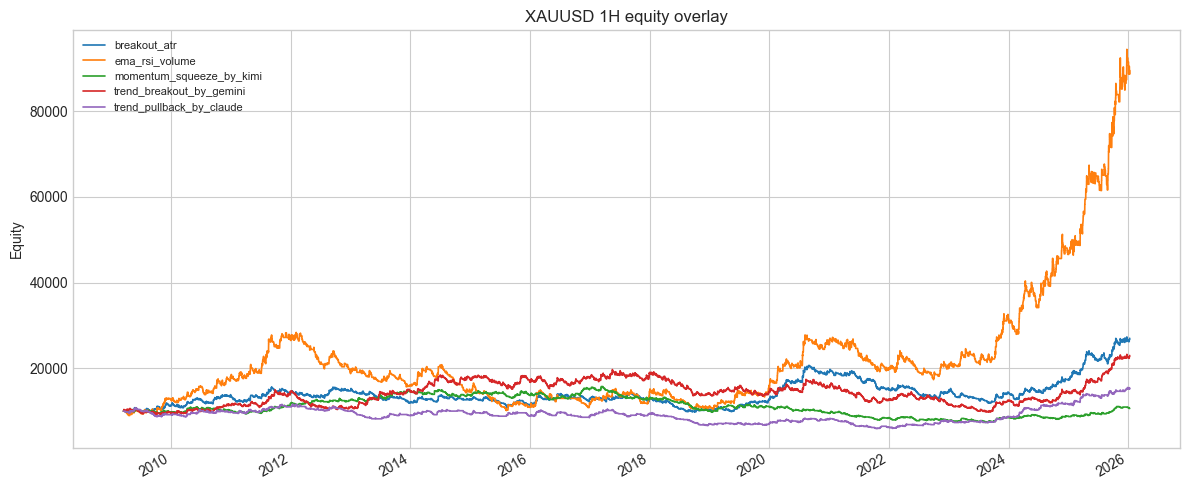

In [5]:
@dataclass
class BacktestResult:
    name: str
    equity: pd.Series
    trades: pd.DataFrame
    metrics: dict
    params: dict = field(default_factory=dict)
    fee: float = FEE
    slippage: float = SLIPPAGE
    commission_per_lot: float = COMMISSION_PER_LOT
    spread: float = SPREAD


def _max_drawdown(equity: np.ndarray) -> float:
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / np.where(peak == 0, np.nan, peak)
    return float(np.nanmin(dd)) if len(dd) else 0.0


def calculate_metrics(equity: pd.Series, trades: pd.DataFrame, initial: float = INITIAL_EQUITY) -> dict:
    eq = equity.dropna()
    if eq.empty:
        return {"error": "empty equity"}
    if not isinstance(eq.index, pd.DatetimeIndex):
        eq.index = pd.to_datetime(eq.index)
    eq = eq[~eq.index.duplicated(keep="last")].sort_index()
    final = float(eq.iloc[-1])
    total_return = final / initial - 1.0
    dt = (eq.index[-1] - eq.index[0]).days
    years = max(dt / 365.25, 1e-9)
    cagr = (final / initial) ** (1 / years) - 1.0 if final > 0 else -1.0
    daily = eq.resample("1D").last().ffill().dropna()
    rets = daily.pct_change().dropna()
    sharpe = float(rets.mean() / rets.std() * np.sqrt(252)) if len(rets) and rets.std() > 0 else 0.0
    downside = rets[rets < 0]
    sortino = float(rets.mean() / downside.std() * np.sqrt(252)) if len(downside) and downside.std() > 0 else 0.0
    max_dd = _max_drawdown(eq.to_numpy(dtype=float))
    calmar = float(cagr / abs(max_dd)) if max_dd < 0 else 0.0

    n = int(len(trades))
    if n:
        wins = trades.loc[trades["pnl"] > 0, "pnl"]
        losses = trades.loc[trades["pnl"] < 0, "pnl"]
        win_rate = float((trades["pnl"] > 0).mean())
        avg_win = float(wins.mean()) if len(wins) else 0.0
        avg_loss = float(losses.mean()) if len(losses) else 0.0
        gross_win = float(wins.sum()) if len(wins) else 0.0
        gross_loss = float(losses.abs().sum()) if len(losses) else 0.0
        profit_factor = gross_win / gross_loss if gross_loss > 0 else np.inf
        expectancy = float(trades["pnl"].mean())
        signs = np.sign(trades["pnl"].to_numpy())
        worst = 0
        cur = 0
        for s in signs:
            if s < 0:
                cur += 1
                worst = max(worst, cur)
            else:
                cur = 0
        recovery = total_return / abs(max_dd) if max_dd < 0 else 0.0
    else:
        win_rate = avg_win = avg_loss = expectancy = recovery = 0.0
        profit_factor = 0.0
        worst = 0

    return {
        "initial_equity": initial,
        "final_equity": final,
        "total_return": total_return,
        "cagr": cagr,
        "sharpe": sharpe,
        "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": float(profit_factor) if np.isfinite(profit_factor) else 999.0,
        "expectancy": expectancy,
        "average_win": avg_win,
        "average_loss": avg_loss,
        "trades": n,
        "average_trade": float(trades["pnl"].mean()) if n else 0.0,
        "longest_losing_streak": int(worst),
        "recovery_factor": recovery,
        "years": years,
    }


def run_backtest(
    signal_df: pd.DataFrame,
    initial_equity: float = INITIAL_EQUITY,
    fee: float = FEE,
    slippage: float = SLIPPAGE,
    commission_per_lot: float = COMMISSION_PER_LOT,
    spread: float = SPREAD,
    risk_pct: float = RISK_PCT,
    contract_size: float = CONTRACT_SIZE,
    name: str = "backtest",
    params: dict | None = None,
) -> BacktestResult:
    need = {"Open", "High", "Low", "Close", "ATR", "signal", "sl_atr", "tp_atr"}
    missing = need - set(signal_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    x = signal_df.sort_values("Datetime").reset_index(drop=True)
    n = len(x)
    opens = x["Open"].to_numpy(float)
    highs = x["High"].to_numpy(float)
    lows = x["Low"].to_numpy(float)
    closes = x["Close"].to_numpy(float)
    atrs = x["ATR"].to_numpy(float)
    signals = x["signal"].to_numpy(float)
    sl_atrs = x["sl_atr"].to_numpy(float)
    tp_atrs = x["tp_atr"].to_numpy(float)
    times = pd.to_datetime(x["Datetime"]).to_numpy()

    equity_val = float(initial_equity)
    equity_curve = np.full(n, np.nan)
    equity_curve[0] = equity_val
    in_pos = False
    direction = 0
    entry_price = sl = tp = lots = 0.0
    entry_i = 0
    trades: list[dict] = []

    for i in range(1, n):
        if equity_val <= 0:
            equity_curve[i:] = 0.0
            break

        if in_pos:
            hit_sl = (direction == 1 and lows[i] <= sl) or (direction == -1 and highs[i] >= sl)
            hit_tp = (direction == 1 and highs[i] >= tp) or (direction == -1 and lows[i] <= tp)
            exit_price = None
            reason = None
            if hit_sl and hit_tp:
                exit_price, reason = sl, "SL"
            elif hit_sl:
                exit_price, reason = sl, "SL"
            elif hit_tp:
                exit_price, reason = tp, "TP"

            if exit_price is not None:
                if direction == 1:
                    exit_price = exit_price * (1.0 - slippage) - spread / 2.0
                else:
                    exit_price = exit_price * (1.0 + slippage) + spread / 2.0
                pnl = direction * (exit_price - entry_price) * lots * contract_size
                pnl -= fee * lots * contract_size * (entry_price + exit_price)
                pnl -= commission_per_lot * lots
                equity_val += pnl
                trades.append(
                    {
                        "entry_time": times[entry_i],
                        "exit_time": times[i],
                        "direction": direction,
                        "entry": entry_price,
                        "exit": exit_price,
                        "lots": lots,
                        "pnl": pnl,
                        "reason": reason,
                        "return_pct": direction * (exit_price / entry_price - 1.0),
                    }
                )
                in_pos = False

        equity_curve[i] = max(equity_val, 0.0)

        if equity_val <= 0:
            continue

        if (not in_pos) and signals[i - 1] != 0 and np.isfinite(atrs[i - 1]) and atrs[i - 1] > 0:
            direction = int(np.sign(signals[i - 1]))
            raw_entry = opens[i]
            if not np.isfinite(raw_entry):
                continue
            if direction == 1:
                entry_price = raw_entry * (1.0 + slippage) + spread / 2.0
            else:
                entry_price = raw_entry * (1.0 - slippage) - spread / 2.0
            sl_dist = float(sl_atrs[i - 1] * atrs[i - 1])
            tp_dist = float(tp_atrs[i - 1] * atrs[i - 1])
            if sl_dist <= 0 or not np.isfinite(sl_dist):
                continue
            if direction == 1:
                sl, tp = entry_price - sl_dist, entry_price + tp_dist
            else:
                sl, tp = entry_price + sl_dist, entry_price - tp_dist
            lots = (equity_val * risk_pct) / (contract_size * sl_dist)
            if lots <= 0 or not np.isfinite(lots):
                continue
            in_pos = True
            entry_i = i

    if in_pos:
        exit_price = closes[-1] * (1.0 - slippage * direction) - direction * spread / 2.0
        pnl = direction * (exit_price - entry_price) * lots * contract_size
        pnl -= fee * lots * contract_size * (entry_price + exit_price)
        pnl -= commission_per_lot * lots
        equity_val += pnl
        equity_curve[-1] = equity_val
        trades.append(
            {
                "entry_time": times[entry_i],
                "exit_time": times[-1],
                "direction": direction,
                "entry": entry_price,
                "exit": exit_price,
                "lots": lots,
                "pnl": pnl,
                "reason": "EOD",
                "return_pct": direction * (exit_price / entry_price - 1.0),
            }
        )

    eq = pd.Series(equity_curve, index=pd.to_datetime(times), name="equity").ffill()
    trade_df = pd.DataFrame(trades)
    metrics = calculate_metrics(eq, trade_df, initial_equity)
    metrics["fee"] = fee
    metrics["slippage"] = slippage
    metrics["commission_per_lot"] = commission_per_lot
    metrics["spread"] = spread
    return BacktestResult(
        name=name,
        equity=eq,
        trades=trade_df,
        metrics=metrics,
        params=params or {},
        fee=fee,
        slippage=slippage,
        commission_per_lot=commission_per_lot,
        spread=spread,
    )


def apply_strategy(df_ind_: pd.DataFrame, name: str | None = None, params: dict | None = None) -> pd.DataFrame:
    strat_name = name or CURRENT_STRATEGY
    if not isinstance(strat_name, str):
        raise TypeError("apply_strategy butuh nama string. Isi CURRENT_STRATEGY atau kirim name=")
    fn = get_strategy(strat_name)
    return fn(df_ind_, params)


def print_metrics(m: dict, title: str = "") -> None:
    if title:
        print(f"\n=== {title} ===")
    keys = [
        "initial_equity", "final_equity", "total_return", "cagr", "sharpe", "sortino",
        "max_drawdown", "calmar", "win_rate", "profit_factor", "expectancy",
        "average_win", "average_loss", "trades", "longest_losing_streak", "recovery_factor",
    ]
    for k in keys:
        v = m.get(k)
        if v is None:
            continue
        if k in {"total_return", "cagr", "max_drawdown", "win_rate"}:
            print(f"{k:24s} {v:10.2%}")
        elif k in {"initial_equity", "final_equity", "expectancy", "average_win", "average_loss"}:
            print(f"{k:24s} {v:10.2f}")
        elif k == "trades":
            print(f"{k:24s} {int(v):10d}")
        else:
            print(f"{k:24s} {v:10.3f}")


def plot_backtest(result: BacktestResult, title: str | None = None) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    result.equity.plot(ax=axes[0], color="C0", lw=1.2)
    axes[0].set_ylabel("Equity")
    axes[0].set_title(title or result.name)
    peak = result.equity.cummax()
    dd = result.equity / peak - 1.0
    dd.plot(ax=axes[1], color="C3", lw=1.0)
    axes[1].set_ylabel("Drawdown")
    axes[1].set_xlabel("Datetime")
    plt.tight_layout()
    plt.show()


PIPELINE: dict[str, dict] = {name: {} for name in STRATEGY_QUEUE}
bt_full = None
signals = None

for CURRENT_STRATEGY in STRATEGY_QUEUE:
    signals = apply_strategy(df_ind, CURRENT_STRATEGY, PARAMS)
    bt_full = run_backtest(signals, name=f"{CURRENT_STRATEGY}_full")
    PIPELINE[CURRENT_STRATEGY]["signals"] = signals
    PIPELINE[CURRENT_STRATEGY]["bt_full"] = bt_full
    print_metrics(bt_full.metrics, f"Full sample — {CURRENT_STRATEGY}")
    if len(STRATEGY_QUEUE) == 1:
        plot_backtest(bt_full, f"{SYMBOL} {TIMEFRAME} {CURRENT_STRATEGY}")
        if len(bt_full.trades):
            display(bt_full.trades.head())

compare_rows = []
for name, pack in PIPELINE.items():
    m = pack["bt_full"].metrics
    compare_rows.append(
        {
            "strategy": name,
            "trades": int(m["trades"]),
            "total_return": m["total_return"],
            "cagr": m["cagr"],
            "sharpe": m["sharpe"],
            "max_drawdown": m["max_drawdown"],
            "win_rate": m["win_rate"],
            "profit_factor": m["profit_factor"],
            "final_equity": m["final_equity"],
        }
    )
compare_df = pd.DataFrame(compare_rows).sort_values("sharpe", ascending=False)
print("\n=== Comparison (full sample) ===")
display(compare_df)

if len(STRATEGY_QUEUE) > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    for name, pack in PIPELINE.items():
        pack["bt_full"].equity.plot(ax=ax, lw=1.2, label=name)
    ax.set_title(f"{SYMBOL} {TIMEFRAME} equity overlay")
    ax.set_ylabel("Equity")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


## 6. Optimization

Grid kecil di **in-sample**. Cari area parameter yang stabil, bukan peak Sharpe.


In-sample rows=88,107  through 2023-12-31
OOS rows=11,976  from 2024-01-01

=== In-sample — breakout_atr ===
initial_equity             10000.00
final_equity               14313.16
total_return                 43.13%
cagr                          2.45%
sharpe                        0.193
sortino                       0.709
max_drawdown                -42.47%
calmar                        0.058
win_rate                     36.06%
profit_factor                 1.028
expectancy                     2.58
average_win                  257.92
average_loss                -141.43
trades                         1675
longest_losing_streak        14.000
recovery_factor               1.016

=== Out-of-sample — breakout_atr ===
initial_equity             10000.00
final_equity               19065.10
total_return                 90.65%
cagr                         37.62%
sharpe                        1.555
sortino                       4.431
max_drawdown                -12.57%
calmar                   

,ema_fast,sharpe,cagr,max_drawdown,trades,total_return
0,10,0.193492,0.024547,-0.424706,1675,0.431316
1,15,0.193492,0.024547,-0.424706,1675,0.431316
2,20,0.193492,0.024547,-0.424706,1675,0.431316
3,25,0.193492,0.024547,-0.424706,1675,0.431316
4,30,0.193492,0.024547,-0.424706,1675,0.431316


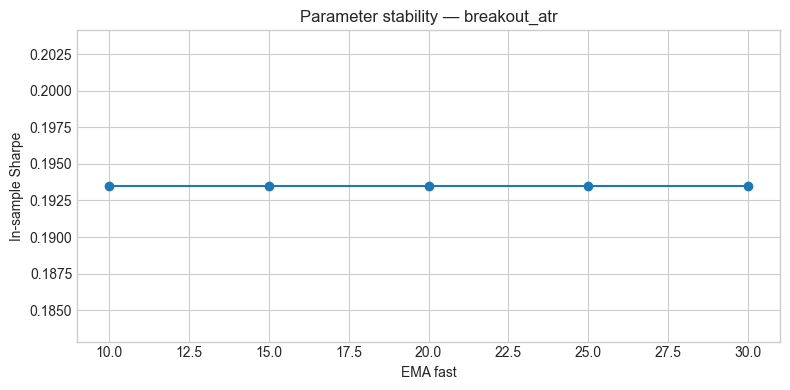

PARAM_STABLE=True  (need >=4 positive-Sharpe neighbours) — breakout_atr

=== In-sample — ema_rsi_volume ===
initial_equity             10000.00
final_equity               31568.00
total_return                215.68%
cagr                          8.08%
sharpe                        0.377
sortino                       0.684
max_drawdown                -64.21%
calmar                        0.126
win_rate                     36.88%
profit_factor                 1.072
expectancy                     8.40
average_win                  339.47
average_loss                -185.01
trades                         2568
longest_losing_streak        18.000
recovery_factor               3.359

=== Out-of-sample — ema_rsi_volume ===
initial_equity             10000.00
final_equity               28355.90
total_return                183.56%
cagr                         67.50%
sharpe                        1.877
sortino                       3.348
max_drawdown                -15.38%
calmar                  

,ema_fast,sharpe,cagr,max_drawdown,trades,total_return
0,10,0.459277,0.106772,-0.485602,2675,3.482213
1,15,0.427805,0.096515,-0.519615,2615,2.905728
2,20,0.377465,0.080842,-0.642052,2568,2.156800
3,25,0.326470,0.065320,-0.606512,2494,1.548895
4,30,0.278473,0.051413,-0.577840,2470,1.098759


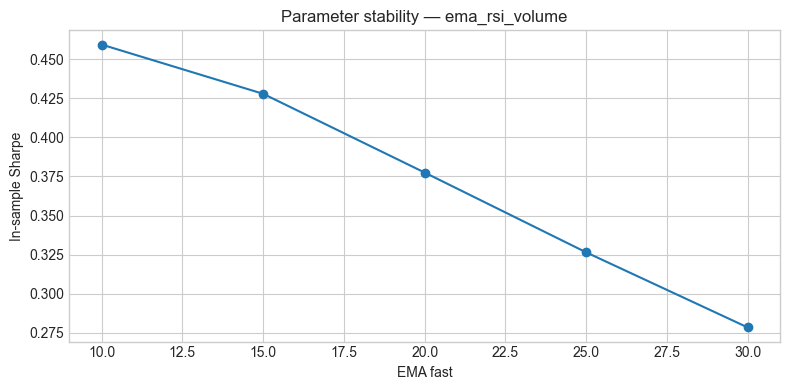

PARAM_STABLE=True  (need >=4 positive-Sharpe neighbours) — ema_rsi_volume

=== In-sample — momentum_squeeze_by_kimi ===
initial_equity             10000.00
final_equity                8561.54
total_return                -14.38%
cagr                         -1.04%
sharpe                       -0.026
sortino                      -0.140
max_drawdown                -53.17%
calmar                       -0.020
win_rate                     34.80%
profit_factor                 0.981
expectancy                    -1.47
average_win                  221.93
average_loss                -120.69
trades                          980
longest_losing_streak        12.000
recovery_factor              -0.271

=== Out-of-sample — momentum_squeeze_by_kimi ===
initial_equity             10000.00
final_equity               12533.20
total_return                 25.33%
cagr                         11.82%
sharpe                        0.868
sortino                      44.544
max_drawdown                -11.54%
ca

,ema_fast,sharpe,cagr,max_drawdown,trades,total_return
0,10,0.022307,-0.004021,-0.520007,1039,-0.057844
1,15,0.019919,-0.004170,-0.501307,1008,-0.059921
2,20,-0.026230,-0.010448,-0.531689,980,-0.143846
3,25,0.004419,-0.005977,-0.509265,948,-0.084837
4,30,-0.012658,-0.008221,-0.488040,937,-0.114913


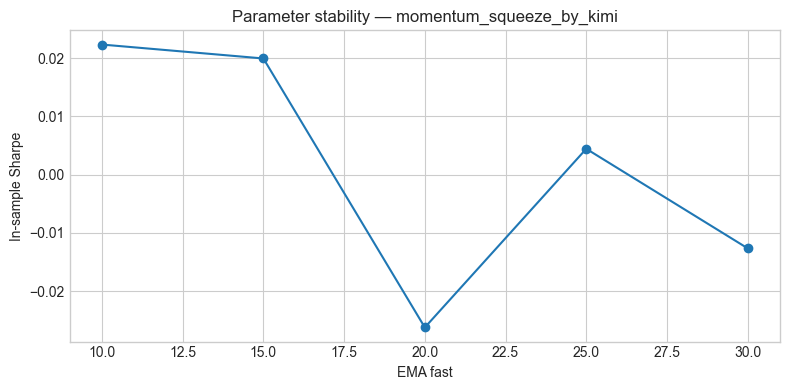

PARAM_STABLE=False  (need >=4 positive-Sharpe neighbours) — momentum_squeeze_by_kimi

=== In-sample — trend_breakout_by_gemini ===
initial_equity             10000.00
final_equity               12440.68
total_return                 24.41%
cagr                          1.49%
sharpe                        0.142
sortino                       0.447
max_drawdown                -50.19%
calmar                        0.030
win_rate                     35.68%
profit_factor                 1.013
expectancy                     1.29
average_win                  272.55
average_loss                -149.16
trades                         1892
longest_losing_streak        15.000
recovery_factor               0.486

=== Out-of-sample — trend_breakout_by_gemini ===
initial_equity             10000.00
final_equity               18672.61
total_return                 86.73%
cagr                         36.21%
sharpe                        1.577
sortino                       4.727
max_drawdown               

,ema_fast,sharpe,cagr,max_drawdown,trades,total_return
0,10,0.211774,0.029552,-0.399823,1985,0.538269
1,15,0.135695,0.013584,-0.483525,1942,0.220818
2,20,0.142036,0.014878,-0.501925,1892,0.244068
3,25,0.130295,0.012498,-0.509253,1864,0.201613
4,30,0.107976,0.008039,-0.477015,1836,0.125691


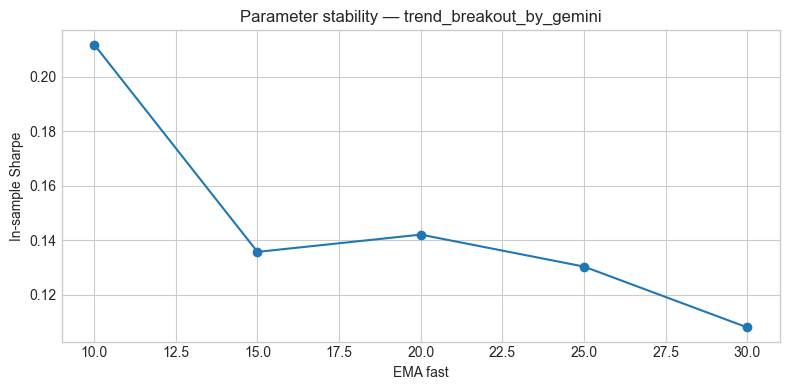

PARAM_STABLE=True  (need >=4 positive-Sharpe neighbours) — trend_breakout_by_gemini

=== In-sample — trend_pullback_by_claude ===
initial_equity             10000.00
final_equity                8699.64
total_return                -13.00%
cagr                         -0.94%
sharpe                       -0.005
sortino                      -0.008
max_drawdown                -49.11%
calmar                       -0.019
win_rate                     34.93%
profit_factor                 0.981
expectancy                    -1.16
average_win                  168.56
average_loss                 -92.27
trades                         1125
longest_losing_streak        17.000
recovery_factor              -0.265

=== Out-of-sample — trend_pullback_by_claude ===
initial_equity             10000.00
final_equity               17654.05
total_return                 76.54%
cagr                         32.49%
sharpe                        1.570
sortino                       2.929
max_drawdown                

,ema_fast,sharpe,cagr,max_drawdown,trades,total_return
0,10,0.138471,0.014040,-0.458071,1446,0.228964
1,15,-0.052095,-0.018637,-0.606143,1254,-0.242842
2,20,-0.004523,-0.009376,-0.491088,1125,-0.130036
3,25,-0.132903,-0.027545,-0.508587,1027,-0.338350
4,30,-0.195921,-0.034088,-0.516993,917,-0.401215


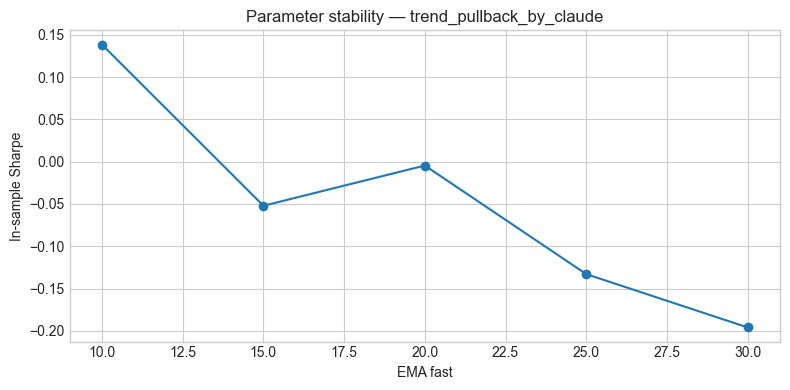

PARAM_STABLE=False  (need >=4 positive-Sharpe neighbours) — trend_pullback_by_claude

=== Comparison IS vs OOS ===


,strategy,is_sharpe,is_return,is_dd,is_trades,oos_sharpe,oos_return,oos_dd,oos_trades
1,ema_rsi_volume,0.377465,2.156800,-0.642052,2568,1.877281,1.835590,-0.153758,448
3,trend_breakout_by_gemini,0.142036,0.244068,-0.501925,1892,1.576912,0.867261,-0.106515,273
4,trend_pullback_by_claude,-0.004523,-0.130036,-0.491088,1125,1.570072,0.765405,-0.073747,192
0,breakout_atr,0.193492,0.431316,-0.424706,1675,1.554739,0.906510,-0.125685,285
2,momentum_squeeze_by_kimi,-0.026230,-0.143846,-0.531689,980,0.868100,0.253320,-0.115350,128


In [6]:
def slice_df(df_: pd.DataFrame, start: str | None = None, end: str | None = None) -> pd.DataFrame:
    ts = pd.to_datetime(df_["Datetime"])
    mask = pd.Series(True, index=df_.index)
    if start:
        mask &= ts >= pd.Timestamp(start)
    if end:
        mask &= ts <= pd.Timestamp(end)
    return df_.loc[mask].copy()


def backtest_params(
    df_ind_: pd.DataFrame,
    params: dict,
    start=None,
    end=None,
    fee=FEE,
    slippage=SLIPPAGE,
    commission_per_lot=COMMISSION_PER_LOT,
    spread=SPREAD,
    name="run",
    strategy_name: str | None = None,
) -> BacktestResult:
    sl = slice_df(df_ind_, start, end)
    sig = apply_strategy(sl, strategy_name or CURRENT_STRATEGY, params)
    return run_backtest(
        sig,
        fee=fee,
        slippage=slippage,
        commission_per_lot=commission_per_lot,
        spread=spread,
        name=name,
        params=params,
    )


is_df = slice_df(df_ind, end=IN_SAMPLE_END)
oos_df = slice_df(df_ind, start=OOS_START)
print(f"In-sample rows={len(is_df):,}  through {IN_SAMPLE_END}")
print(f"OOS rows={len(oos_df):,}  from {OOS_START}")

oos_compare_rows = []
bt_is = None
bt_oos = None
PARAM_STABLE = False
grid_df = pd.DataFrame()

for CURRENT_STRATEGY in STRATEGY_QUEUE:
    bt_is = backtest_params(df_ind, PARAMS, end=IN_SAMPLE_END, name="in_sample")
    bt_oos = backtest_params(df_ind, PARAMS, start=OOS_START, name="oos")
    PIPELINE[CURRENT_STRATEGY]["bt_is"] = bt_is
    PIPELINE[CURRENT_STRATEGY]["bt_oos"] = bt_oos
    print_metrics(bt_is.metrics, f"In-sample — {CURRENT_STRATEGY}")
    print_metrics(bt_oos.metrics, f"Out-of-sample — {CURRENT_STRATEGY}")
    oos_compare_rows.append(
        {
            "strategy": CURRENT_STRATEGY,
            "is_sharpe": bt_is.metrics["sharpe"],
            "is_return": bt_is.metrics["total_return"],
            "is_dd": bt_is.metrics["max_drawdown"],
            "is_trades": int(bt_is.metrics["trades"]),
            "oos_sharpe": bt_oos.metrics["sharpe"],
            "oos_return": bt_oos.metrics["total_return"],
            "oos_dd": bt_oos.metrics["max_drawdown"],
            "oos_trades": int(bt_oos.metrics["trades"]),
        }
    )

    if CURRENT_STRATEGY not in DEEP_QUEUE:
        PIPELINE[CURRENT_STRATEGY]["PARAM_STABLE"] = False
        PIPELINE[CURRENT_STRATEGY]["grid_df"] = pd.DataFrame()
        continue

    grid_fast = [10, 15, 20, 25, 30]
    grid_rows = []
    for fast in grid_fast:
        p = {**PARAMS, "ema_fast": fast}
        r = backtest_params(df_ind, p, end=IN_SAMPLE_END, name=f"ema_fast_{fast}")
        grid_rows.append(
            {
                "ema_fast": fast,
                "sharpe": r.metrics["sharpe"],
                "cagr": r.metrics["cagr"],
                "max_drawdown": r.metrics["max_drawdown"],
                "trades": r.metrics["trades"],
                "total_return": r.metrics["total_return"],
            }
        )

    grid_df = pd.DataFrame(grid_rows)
    PIPELINE[CURRENT_STRATEGY]["grid_df"] = grid_df
    print(f"\nIn-sample EMA fast sweep (slow=50) — {CURRENT_STRATEGY}:")
    display(grid_df)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(grid_df["ema_fast"], grid_df["sharpe"], marker="o")
    ax.set_xlabel("EMA fast")
    ax.set_ylabel("In-sample Sharpe")
    ax.set_title(f"Parameter stability — {CURRENT_STRATEGY}")
    plt.tight_layout()
    plt.show()

    sharpes = grid_df["sharpe"].to_numpy()
    PARAM_STABLE = bool(np.isfinite(sharpes).all() and (sharpes > 0).sum() >= 4)
    PIPELINE[CURRENT_STRATEGY]["PARAM_STABLE"] = PARAM_STABLE
    print(f"PARAM_STABLE={PARAM_STABLE}  (need >=4 positive-Sharpe neighbours) — {CURRENT_STRATEGY}")

oos_compare_df = pd.DataFrame(oos_compare_rows).sort_values("oos_sharpe", ascending=False)
print("\n=== Comparison IS vs OOS ===")
display(oos_compare_df)
if not DEEP_QUEUE:
    print("Deep pipeline dilewati. Set MULTI_DEEP=True untuk walk-forward, robustness, Monte Carlo, dan export.")


## 7. Walk-forward

Develop 3 tahun, validate 1 tahun, geser 1 tahun. Parameter `ema_fast` dipilih di jendela develop, diuji di validate. Bukan `fit()` model.


In [7]:
def walk_forward_windows(start: str, end: str, train_years: int = 3, test_years: int = 1, step_years: int = 1):
    windows = []
    t0 = pd.Timestamp(start)
    t_end = pd.Timestamp(end)
    while True:
        dev_end = t0 + pd.DateOffset(years=train_years) - pd.Timedelta(days=1)
        val_start = dev_end + pd.Timedelta(days=1)
        val_end = val_start + pd.DateOffset(years=test_years) - pd.Timedelta(days=1)
        if val_end > t_end:
            break
        windows.append((str(t0.date()), str(dev_end.date()), str(val_start.date()), str(val_end.date())))
        t0 = t0 + pd.DateOffset(years=step_years)
    return windows


wf_start = str(pd.to_datetime(df_ind["Datetime"]).min().date())
wf_end = str(pd.to_datetime(df_ind["Datetime"]).max().date())
windows = walk_forward_windows(wf_start, wf_end)
print(f"{len(windows)} walk-forward windows")

wf_df = pd.DataFrame()
WF_PASS = False
if not DEEP_QUEUE:
    print("Skip walk-forward (screening only). Set MULTI_DEEP=True untuk menjalankan.")
else:
    for CURRENT_STRATEGY in DEEP_QUEUE:
        wf_rows = []
        for dev_s, dev_e, val_s, val_e in windows:
            best = None
            for fast in [15, 20, 25]:
                p = {**PARAMS, "ema_fast": fast}
                r = backtest_params(df_ind, p, start=dev_s, end=dev_e, name="dev")
                score = r.metrics["sharpe"]
                if best is None or score > best[0]:
                    best = (score, p, r.metrics)
            if best is None:
                continue
            val = backtest_params(df_ind, best[1], start=val_s, end=val_e, name="val")
            wf_rows.append(
                {
                    "develop": f"{dev_s} -> {dev_e}",
                    "validate": f"{val_s} -> {val_e}",
                    "chosen_ema_fast": best[1]["ema_fast"],
                    "dev_sharpe": best[0],
                    "val_sharpe": val.metrics["sharpe"],
                    "val_return": val.metrics["total_return"],
                    "val_max_dd": val.metrics["max_drawdown"],
                    "val_trades": val.metrics["trades"],
                }
            )

        wf_df = pd.DataFrame(wf_rows)
        PIPELINE[CURRENT_STRATEGY]["wf_df"] = wf_df
        print(f"\nWalk-forward — {CURRENT_STRATEGY}")
        display(wf_df)
        WF_PASS = bool(len(wf_df) and (wf_df["val_sharpe"] > 0).mean() >= 0.5 and wf_df["val_return"].median() > 0)
        PIPELINE[CURRENT_STRATEGY]["WF_PASS"] = WF_PASS
        print(
            f"WF_PASS={WF_PASS}  median val return={wf_df['val_return'].median():.2%}  "
            f"pct positive Sharpe={(wf_df['val_sharpe']>0).mean():.0%}  — {CURRENT_STRATEGY}"
        )


13 walk-forward windows

Walk-forward — breakout_atr


,develop,validate,chosen_ema_fast,dev_sharpe,val_sharpe,val_return,val_max_dd,val_trades
0,2009-03-15 -> 2012-03-14,2012-03-15 -> 2013-03-14,15,0.631523,0.329506,0.049794,-0.101650,106
1,2010-03-15 -> 2013-03-14,2013-03-15 -> 2014-03-14,15,0.581157,-0.551050,-0.092686,-0.186423,98
2,2011-03-15 -> 2014-03-14,2014-03-15 -> 2015-03-14,15,0.223731,-0.110846,-0.028089,-0.088881,76
3,2012-03-15 -> 2015-03-14,2015-03-15 -> 2016-03-14,15,-0.118850,0.331337,0.050252,-0.181868,114
4,2013-03-15 -> 2016-03-14,2016-03-15 -> 2017-03-14,15,-0.155536,-0.031901,-0.016038,-0.130954,106
5,2014-03-15 -> 2017-03-14,2017-03-15 -> 2018-03-14,15,0.048111,-0.087369,-0.031404,-0.159210,120
6,2015-03-15 -> 2018-03-14,2018-03-15 -> 2019-03-14,15,0.027590,-0.453296,-0.096175,-0.227154,109
7,2016-03-15 -> 2019-03-14,2019-03-15 -> 2020-03-14,15,-0.243307,1.757651,0.417410,-0.083683,130
8,2017-03-15 -> 2020-03-14,2020-03-15 -> 2021-03-14,15,0.395346,1.048327,0.222119,-0.111096,110
9,2018-03-15 -> 2021-03-14,2021-03-15 -> 2022-03-14,15,0.788129,-0.818614,-0.147138,-0.240316,126


WF_PASS=False  median val return=-1.60%  pct positive Sharpe=46%  — breakout_atr

Walk-forward — ema_rsi_volume


,develop,validate,chosen_ema_fast,dev_sharpe,val_sharpe,val_return,val_max_dd,val_trades
0,2009-03-15 -> 2012-03-14,2012-03-15 -> 2013-03-14,20,1.229674,-1.335494,-0.278598,-0.284341,144
1,2010-03-15 -> 2013-03-14,2013-03-15 -> 2014-03-14,15,0.850073,0.190570,0.026716,-0.206398,153
2,2011-03-15 -> 2014-03-14,2014-03-15 -> 2015-03-14,15,0.434227,-0.651810,-0.188863,-0.274198,138
3,2012-03-15 -> 2015-03-14,2015-03-15 -> 2016-03-14,15,-0.408922,0.396611,0.094289,-0.285623,192
4,2013-03-15 -> 2016-03-14,2016-03-15 -> 2017-03-14,15,0.031024,-0.375995,-0.095327,-0.228749,128
5,2014-03-15 -> 2017-03-14,2017-03-15 -> 2018-03-14,15,-0.169292,0.584012,0.164490,-0.211582,200
6,2015-03-15 -> 2018-03-14,2018-03-15 -> 2019-03-14,15,0.262507,-0.233063,-0.089372,-0.319326,169
7,2016-03-15 -> 2019-03-14,2019-03-15 -> 2020-03-14,15,0.039565,1.694167,0.604666,-0.096826,197
8,2017-03-15 -> 2020-03-14,2020-03-15 -> 2021-03-14,15,0.702660,0.974150,0.276258,-0.142043,166
9,2018-03-15 -> 2021-03-14,2021-03-15 -> 2022-03-14,15,0.853912,-0.516175,-0.156003,-0.331133,212


WF_PASS=True  median val return=2.67%  pct positive Sharpe=54%  — ema_rsi_volume

Walk-forward — momentum_squeeze_by_kimi


...

WF_PASS=True  median val return=2.00%  pct positive Sharpe=62%  — momentum_squeeze_by_kimi

Walk-forward — trend_breakout_by_gemini


,develop,validate,chosen_ema_fast,dev_sharpe,val_sharpe,val_return,val_max_dd,val_trades
0,2009-03-15 -> 2012-03-14,2012-03-15 -> 2013-03-14,25,0.450459,-0.232717,-0.058275,-0.190041,125
1,2010-03-15 -> 2013-03-14,2013-03-15 -> 2014-03-14,25,0.480239,1.231122,0.270517,-0.075273,116
2,2011-03-15 -> 2014-03-14,2014-03-15 -> 2015-03-14,25,0.543476,0.931085,0.198378,-0.117020,110
3,2012-03-15 -> 2015-03-14,2015-03-15 -> 2016-03-14,25,0.639186,-0.606344,-0.117962,-0.205043,133
4,2013-03-15 -> 2016-03-14,2016-03-15 -> 2017-03-14,20,0.690706,0.408471,0.067584,-0.118132,130
5,2014-03-15 -> 2017-03-14,2017-03-15 -> 2018-03-14,15,0.501558,-0.105185,-0.038778,-0.149624,137
6,2015-03-15 -> 2018-03-14,2018-03-15 -> 2019-03-14,15,0.095776,-0.510417,-0.099996,-0.208923,126
7,2016-03-15 -> 2019-03-14,2019-03-15 -> 2020-03-14,15,-0.065220,0.051243,-0.004209,-0.163152,137
8,2017-03-15 -> 2020-03-14,2020-03-15 -> 2021-03-14,15,-0.225133,0.291604,0.051286,-0.125871,139
9,2018-03-15 -> 2021-03-14,2021-03-15 -> 2022-03-14,15,-0.089860,-0.470754,-0.097792,-0.225028,135


WF_PASS=False  median val return=-0.42%  pct positive Sharpe=54%  — trend_breakout_by_gemini

Walk-forward — trend_pullback_by_claude


,develop,validate,chosen_ema_fast,dev_sharpe,val_sharpe,val_return,val_max_dd,val_trades
0,2009-03-15 -> 2012-03-14,2012-03-15 -> 2013-03-14,20,0.264169,-1.679174,-0.201214,-0.201988,61
1,2010-03-15 -> 2013-03-14,2013-03-15 -> 2014-03-14,20,0.040616,0.515205,0.068610,-0.074042,63
2,2011-03-15 -> 2014-03-14,2014-03-15 -> 2015-03-14,20,0.020845,-0.251001,-0.043651,-0.110324,55
3,2012-03-15 -> 2015-03-14,2015-03-15 -> 2016-03-14,20,-0.313774,0.374742,0.054852,-0.108584,77
4,2013-03-15 -> 2016-03-14,2016-03-15 -> 2017-03-14,20,0.316686,-0.151059,-0.033547,-0.153763,71
5,2014-03-15 -> 2017-03-14,2017-03-15 -> 2018-03-14,20,0.002215,-0.466880,-0.081232,-0.168765,83
6,2015-03-15 -> 2018-03-14,2018-03-15 -> 2019-03-14,25,-0.006406,-0.266844,-0.036936,-0.168613,56
7,2016-03-15 -> 2019-03-14,2019-03-15 -> 2020-03-14,25,-0.123462,0.415773,0.056340,-0.072542,71
8,2017-03-15 -> 2020-03-14,2020-03-15 -> 2021-03-14,15,0.014214,0.186127,0.022499,-0.171215,84
9,2018-03-15 -> 2021-03-14,2021-03-15 -> 2022-03-14,15,0.144402,-0.134088,-0.032723,-0.185298,94


WF_PASS=True  median val return=2.25%  pct positive Sharpe=54%  — trend_pullback_by_claude


## 8. Robustness

Parameter perturbation (EMA ±2) dan cost stress (fee/slippage ×1/×2/×3).


In [8]:
perturb_pairs = [(18, 48), (19, 49), (20, 50), (21, 51), (22, 52)]
perturb_df = pd.DataFrame()
PERTURB_STABLE = False
stress_df = pd.DataFrame()
COST_PASS = False
stress_result_x1 = None

if not DEEP_QUEUE:
    print("Skip robustness (screening only). Set MULTI_DEEP=True untuk menjalankan.")
else:
    for CURRENT_STRATEGY in DEEP_QUEUE:
        perturb_rows = []
        for fast, slow in perturb_pairs:
            p = {**PARAMS, "ema_fast": fast, "ema_slow": slow}
            r = backtest_params(df_ind, p, start=OOS_START, name=f"{fast}/{slow}")
            perturb_rows.append(
                {
                    "ema": f"{fast}/{slow}",
                    "oos_return": r.metrics["total_return"],
                    "oos_sharpe": r.metrics["sharpe"],
                    "oos_dd": r.metrics["max_drawdown"],
                    "trades": r.metrics["trades"],
                }
            )
        perturb_df = pd.DataFrame(perturb_rows)
        PIPELINE[CURRENT_STRATEGY]["perturb_df"] = perturb_df
        print(f"OOS parameter perturbation — {CURRENT_STRATEGY}")
        display(perturb_df)
        PERTURB_STABLE = bool((perturb_df["oos_return"] > 0).all()) if len(perturb_df) else False
        PIPELINE[CURRENT_STRATEGY]["PERTURB_STABLE"] = PERTURB_STABLE
        print(f"PERTURB_STABLE={PERTURB_STABLE}  — {CURRENT_STRATEGY}")

        stress_rows = []
        stress_result_x1 = None
        for mult in (1, 2, 3):
            r = backtest_params(
                df_ind,
                PARAMS,
                start=OOS_START,
                fee=FEE * mult,
                slippage=SLIPPAGE * mult,
                commission_per_lot=COMMISSION_PER_LOT * mult,
                spread=SPREAD * mult,
                name=f"cost_x{mult}",
            )
            if mult == 1:
                stress_result_x1 = r
            stress_rows.append(
                {
                    "cost_mult": mult,
                    "fee": FEE * mult,
                    "commission": COMMISSION_PER_LOT * mult,
                    "spread": SPREAD * mult,
                    "slippage": SLIPPAGE * mult,
                    "oos_return": r.metrics["total_return"],
                    "oos_sharpe": r.metrics["sharpe"],
                    "oos_dd": r.metrics["max_drawdown"],
                    "trades": r.metrics["trades"],
                }
            )
        stress_df = pd.DataFrame(stress_rows)
        PIPELINE[CURRENT_STRATEGY]["stress_df"] = stress_df
        print(f"\nOOS cost stress — {CURRENT_STRATEGY}")
        display(stress_df)
        COST_PASS = bool((stress_df.loc[stress_df["cost_mult"] == 2, "oos_return"].iloc[0] > 0) if len(stress_df) else False)
        PIPELINE[CURRENT_STRATEGY]["COST_PASS"] = COST_PASS
        print(f"COST_PASS={COST_PASS}  (2x cost still profitable) — {CURRENT_STRATEGY}")


OOS parameter perturbation — breakout_atr


,ema,oos_return,oos_sharpe,oos_dd,trades
0,18/48,0.90651,1.554739,-0.125685,285
1,19/49,0.90651,1.554739,-0.125685,285
2,20/50,0.90651,1.554739,-0.125685,285
3,21/51,0.90651,1.554739,-0.125685,285
4,22/52,0.90651,1.554739,-0.125685,285


PERTURB_STABLE=True  — breakout_atr

OOS cost stress — breakout_atr


,cost_mult,fee,commission,spread,slippage,oos_return,oos_sharpe,oos_dd,trades
0,1,0.0,7.0,0.25,0.0001,0.906510,1.554739,-0.125685,285
1,2,0.0,14.0,0.50,0.0002,0.616192,1.171059,-0.125941,283
2,3,0.0,21.0,0.75,0.0003,0.314879,0.706224,-0.144444,283


COST_PASS=True  (2x cost still profitable) — breakout_atr
OOS parameter perturbation — ema_rsi_volume


...

COST_PASS=True  (2x cost still profitable) — trend_breakout_by_gemini
OOS parameter perturbation — trend_pullback_by_claude


,ema,oos_return,oos_sharpe,oos_dd,trades
0,18/48,0.685229,1.384555,-0.100922,205
1,19/49,0.755079,1.485898,-0.075366,204
2,20/50,0.765405,1.570072,-0.073747,192
3,21/51,0.786944,1.650889,-0.054574,182
4,22/52,0.806266,1.669226,-0.070809,178


PERTURB_STABLE=True  — trend_pullback_by_claude

OOS cost stress — trend_pullback_by_claude


,cost_mult,fee,commission,spread,slippage,oos_return,oos_sharpe,oos_dd,trades
0,1,0.0,7.0,0.25,0.0001,0.765405,1.570072,-0.073747,192
1,2,0.0,14.0,0.50,0.0002,0.545692,1.224938,-0.078426,193
2,3,0.0,21.0,0.75,0.0003,0.297225,0.761667,-0.091989,195


COST_PASS=True  (2x cost still profitable) — trend_pullback_by_claude


## 9. Monte Carlo

Empat mode pada **hasil trade**, bukan acak harga: shuffle, bootstrap, perturbasi return, slippage random.



Shuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — breakout_atr


,label,n_sims,median_final,p5_final,p25_final,p50_final,p75_final,p95_final,median_max_dd,p95_worst_dd,prob_loss,prob_dd_gt_30
0,shuffle,10000,19065.095369,19065.095369,19065.095369,19065.095369,19065.095369,19065.095369,-0.124337,-0.211406,0.0000,0.0046
1,bootstrap,10000,19025.493208,13295.345835,16689.793107,19025.493208,21290.747201,24783.566361,-0.128334,-0.252898,0.0045,0.0210
2,perturb,10000,19064.289502,18506.142884,18836.186508,19064.289502,19299.251099,19639.752452,-0.125622,-0.138674,0.0000,0.0000
3,slippage_mc,10000,14452.387517,14229.680132,14361.979263,14452.387517,14547.068311,14679.428431,-0.201599,-0.208738,0.0000,0.0000


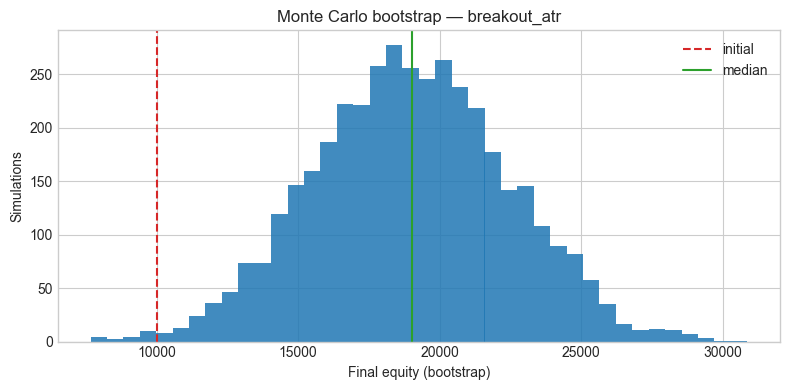

MC_PASS=True  P(loss)=0.45%  median=19,025  — breakout_atr

Shuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — ema_rsi_volume


,label,n_sims,median_final,p5_final,p25_final,p50_final,p75_final,p95_final,median_max_dd,p95_worst_dd,prob_loss,prob_dd_gt_30
0,shuffle,10000,28355.898771,28355.898771,28355.898771,28355.898771,28355.898771,28355.898771,-0.154589,-0.276757,0.0000,0.0304
1,bootstrap,10000,28455.973429,19015.721072,24635.104022,28455.973429,32129.184204,37657.275449,-0.159229,-0.312021,0.0006,0.0607
2,perturb,10000,28341.691291,27425.880488,27964.596210,28341.691291,28729.613717,29297.334971,-0.154189,-0.166987,0.0000,0.0000
3,slippage_mc,10000,19197.806145,18833.175393,19045.397306,19197.806145,19348.376497,19567.524639,-0.213035,-0.219299,0.0000,0.0000


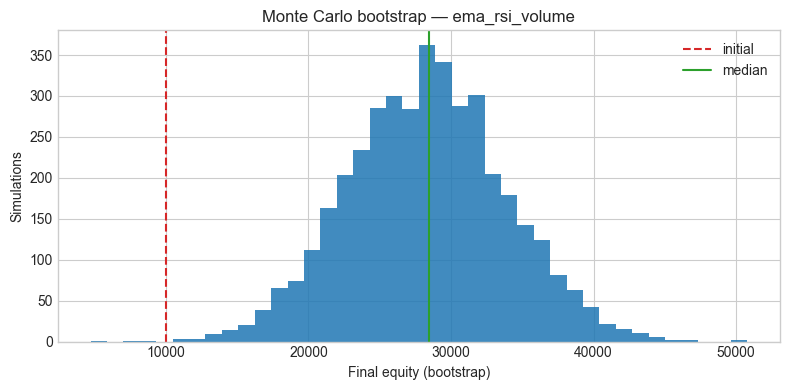

MC_PASS=True  P(loss)=0.06%  median=28,456  — ema_rsi_volume

Shuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — momentum_squeeze_by_kimi


,label,n_sims,median_final,p5_final,p25_final,p50_final,p75_final,p95_final,median_max_dd,p95_worst_dd,prob_loss,prob_dd_gt_30
0,shuffle,10000,12533.202128,12533.202128,12533.202128,12533.202128,12533.202128,12533.202128,-0.098907,-0.158684,0.0000,0.0001
1,bootstrap,10000,12521.956993,9603.127170,11322.954761,12521.956993,13702.550944,15486.853611,-0.102041,-0.207567,0.0765,0.0061
2,perturb,10000,12533.925065,12236.434082,12413.981086,12533.925065,12652.049798,12824.644803,-0.116027,-0.126241,0.0000,0.0000
3,slippage_mc,10000,10938.710665,10821.871491,10889.803618,10938.710665,10986.978433,11055.339018,-0.154686,-0.160321,0.0000,0.0000


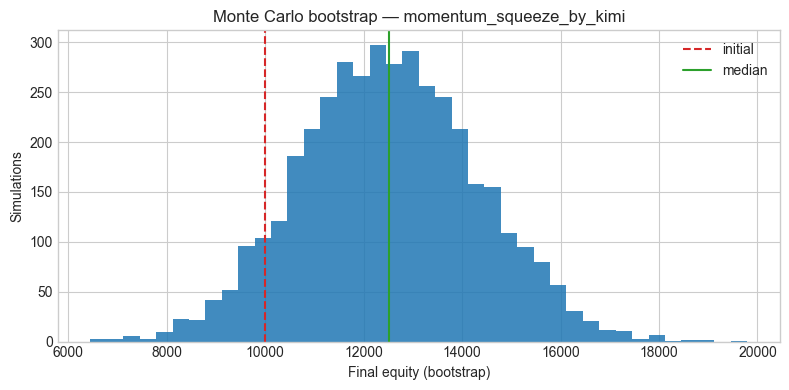

MC_PASS=True  P(loss)=7.65%  median=12,522  — momentum_squeeze_by_kimi

Shuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — trend_breakout_by_gemini


,label,n_sims,median_final,p5_final,p25_final,p50_final,p75_final,p95_final,median_max_dd,p95_worst_dd,prob_loss,prob_dd_gt_30
0,shuffle,10000,18672.614974,18672.614974,18672.614974,18672.614974,18672.614974,18672.614974,-0.112305,-0.188620,0.0000,0.0011
1,bootstrap,10000,18627.494676,13542.347106,16535.961346,18627.494676,20788.766935,23857.899176,-0.115118,-0.217647,0.0025,0.0076
2,perturb,10000,18676.407474,18147.349465,18453.550524,18676.407474,18893.746373,19197.226140,-0.107602,-0.115914,0.0000,0.0000
3,slippage_mc,10000,14743.832445,14549.406061,14664.034068,14743.832445,14825.779959,14941.161552,-0.161657,-0.169274,0.0000,0.0000


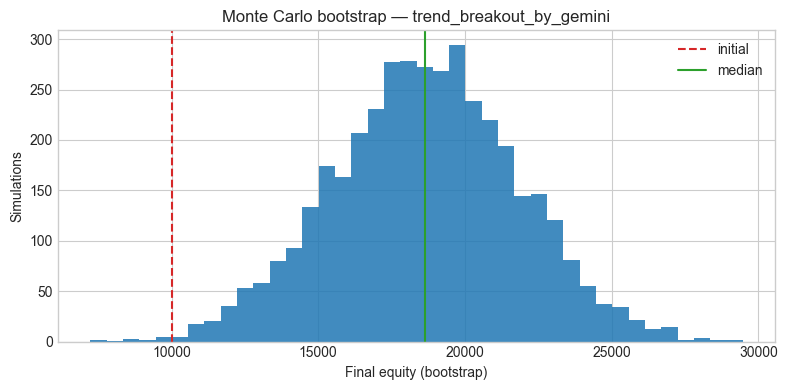

MC_PASS=True  P(loss)=0.25%  median=18,627  — trend_breakout_by_gemini

Shuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — trend_pullback_by_claude


,label,n_sims,median_final,p5_final,p25_final,p50_final,p75_final,p95_final,median_max_dd,p95_worst_dd,prob_loss,prob_dd_gt_30
0,shuffle,10000,17654.048567,17654.048567,17654.048567,17654.048567,17654.048567,17654.048567,-0.106029,-0.177846,0.0000,0.0007
1,bootstrap,10000,17632.004580,12865.468169,15662.265621,17632.004580,19590.802167,22395.718137,-0.109777,-0.211742,0.0029,0.0068
2,perturb,10000,17653.904237,17171.330463,17450.533250,17653.904237,17857.708575,18143.096181,-0.073794,-0.082634,0.0000,0.0000
3,slippage_mc,10000,14389.895155,14196.649856,14308.855056,14389.895155,14469.874692,14587.590864,-0.107783,-0.112328,0.0000,0.0000


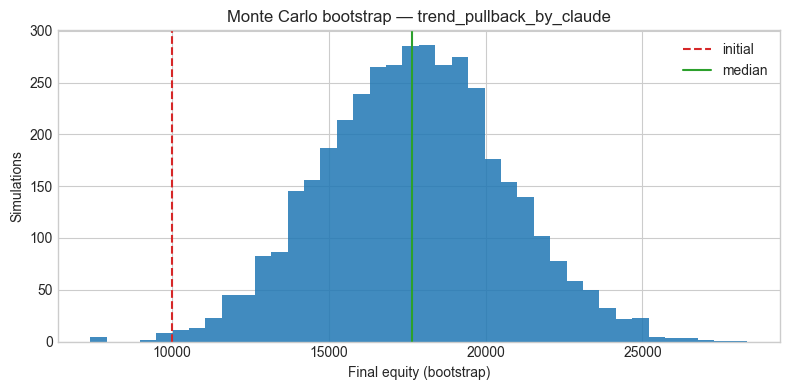

MC_PASS=True  P(loss)=0.29%  median=17,632  — trend_pullback_by_claude


In [9]:
def max_dd_matrix(equity: np.ndarray) -> np.ndarray:
    peak = np.maximum.accumulate(equity, axis=1)
    dd = (equity - peak) / np.where(peak == 0, np.nan, peak)
    return np.nanmin(dd, axis=1)


def run_monte_carlo(trades: pd.DataFrame, n_sims: int = N_MC_SIMS, seed: int = MC_SEED, initial: float = INITIAL_EQUITY) -> dict:
    if trades is None or trades.empty:
        return {"error": "no trades", "n": 0}
    pnls = trades["pnl"].to_numpy(float)
    n = len(pnls)
    rng = np.random.default_rng(seed)
    out = {}

    def summarize(finals: np.ndarray, maxdds: np.ndarray, label: str) -> dict:
        return {
            "label": label,
            "n_sims": int(len(finals)),
            "median_final": float(np.median(finals)),
            "p5_final": float(np.percentile(finals, 5)),
            "p25_final": float(np.percentile(finals, 25)),
            "p50_final": float(np.percentile(finals, 50)),
            "p75_final": float(np.percentile(finals, 75)),
            "p95_final": float(np.percentile(finals, 95)),
            "median_max_dd": float(np.median(maxdds)),
            "p95_worst_dd": float(np.percentile(maxdds, 5)),
            "prob_loss": float((finals < initial).mean()),
            "prob_dd_gt_30": float((maxdds < -0.30).mean()),
        }

    # A. shuffle
    order = np.argsort(rng.random((n_sims, n)), axis=1)
    seq = pnls[order]
    eq = initial + np.cumsum(seq, axis=1)
    eq = np.concatenate([np.full((n_sims, 1), initial), eq], axis=1)
    out["shuffle"] = summarize(eq[:, -1], max_dd_matrix(eq), "shuffle")

    # B. bootstrap
    idx = rng.integers(0, n, size=(n_sims, n))
    seq = pnls[idx]
    eq = initial + np.cumsum(seq, axis=1)
    eq = np.concatenate([np.full((n_sims, 1), initial), eq], axis=1)
    out["bootstrap"] = summarize(eq[:, -1], max_dd_matrix(eq), "bootstrap")

    # C. perturb returns
    noise = rng.normal(0.0, 0.10, size=(n_sims, n))
    seq = pnls * (1.0 + noise)
    eq = initial + np.cumsum(seq, axis=1)
    eq = np.concatenate([np.full((n_sims, 1), initial), eq], axis=1)
    out["perturb"] = summarize(eq[:, -1], max_dd_matrix(eq), "perturb")

    # D. extra slippage as random cost on notional proxy
    extra = rng.uniform(0.0001, 0.0012, size=(n_sims, n))
    notionals = (trades["entry"].to_numpy(float) * trades["lots"].to_numpy(float) * CONTRACT_SIZE)
    seq = pnls - extra * notionals
    eq = initial + np.cumsum(seq, axis=1)
    eq = np.concatenate([np.full((n_sims, 1), initial), eq], axis=1)
    out["slippage_mc"] = summarize(eq[:, -1], max_dd_matrix(eq), "slippage_mc")
    return out


mc = {}
mc_table = pd.DataFrame()
mc_source = None
MC_PASS = False
boot = {}

if not DEEP_QUEUE:
    print("Skip Monte Carlo (screening only). Set MULTI_DEEP=True untuk menjalankan.")
else:
    for CURRENT_STRATEGY in DEEP_QUEUE:
        pack = PIPELINE[CURRENT_STRATEGY]
        bt_oos = pack["bt_oos"]
        bt_full = pack["bt_full"]
        mc_source = bt_oos if len(bt_oos.trades) else bt_full
        mc = run_monte_carlo(mc_source.trades)
        mc_table = pd.DataFrame(mc.values())
        pack["mc"] = mc
        pack["mc_source"] = mc_source
        print(f"\nShuffle keeps sum(PnL) fixed; use it for drawdown path risk, not final equity. — {CURRENT_STRATEGY}")
        display(mc_table)

        boot = mc.get("bootstrap", {})
        fig, ax = plt.subplots(figsize=(8, 4))
        if len(mc_source.trades):
            pnls = mc_source.trades["pnl"].to_numpy(float)
            rng = np.random.default_rng(MC_SEED)
            idx = rng.integers(0, len(pnls), size=(min(N_MC_SIMS, 4000), len(pnls)))
            finals = INITIAL_EQUITY + pnls[idx].sum(axis=1)
            ax.hist(finals, bins=40, color="C0", alpha=0.85)
            ax.axvline(INITIAL_EQUITY, color="C3", ls="--", label="initial")
            ax.axvline(boot.get("median_final", np.nan), color="C2", label="median")
            ax.set_xlabel("Final equity (bootstrap)")
            ax.set_ylabel("Simulations")
            ax.set_title(f"Monte Carlo bootstrap — {CURRENT_STRATEGY}")
            ax.legend()
            plt.tight_layout()
            plt.show()

        MC_PASS = bool(boot.get("prob_loss", 1) < 0.15 and boot.get("median_final", 0) > INITIAL_EQUITY)
        pack["MC_PASS"] = MC_PASS
        print(f"MC_PASS={MC_PASS}  P(loss)={boot.get('prob_loss', float('nan')):.2%}  median={boot.get('median_final', float('nan')):,.0f}  — {CURRENT_STRATEGY}")


## 10. Strategy preview after Monte Carlo

Tampilan strategy **setelah** biaya, robustness, dan Monte Carlo — bukan hasil in-sample. Dipakai untuk memutuskan apakah aturan ini layak diekspor ke MQL5.

Isi preview:

- logika entry/exit yang akan ditiru EA
- parameter + risk yang disarankan dari distribusi Monte Carlo
- chart harga + sinyal (OOS)
- equity OOS vs pita ketidakpastian Monte Carlo (P5 / P50 / P95)


### XAUUSD 1H — `breakout_atr`

**Logika (siap MQL5)**

LONG jika Close menembus High rolling lookback (shift 1, tanpa look-ahead).
SHORT tidak dipakai.
Exit: SL = sl_atr * ATR, TP = tp_atr * ATR.
Execution: next bar open.

| Item | Nilai |
|---|---|
| EMA fast / slow | 20 / 50 |
| RSI period / threshold | 14 / 50 |
| SL / TP | 2.0 ATR / 4.0 ATR |
| Volume filter | OFF (data volume mati) |
| Execution | next bar open, 1 posisi |
| OOS return | 90.7% |
| OOS Sharpe (daily) | 1.55 |
| OOS max DD | -12.6% |
| Trades OOS | 285 |
| MC median equity | 19,025 |
| MC 5th pct equity | 13,295 |
| MC P(loss) | 0.45% |
| MC 95% worst DD | -25.3% |
| Risk backtest | 1.00% / trade |
| **Risk disarankan live** | **0.99% / trade** (skala agar 95% DD ~ 25%) |
| Hard stop DD | 25.3% |


Neighbour paling stabil di OOS (perturbasi, bukan peak IS): EMA 18/48  return=90.7%  Sharpe=1.55  DD=-12.6%


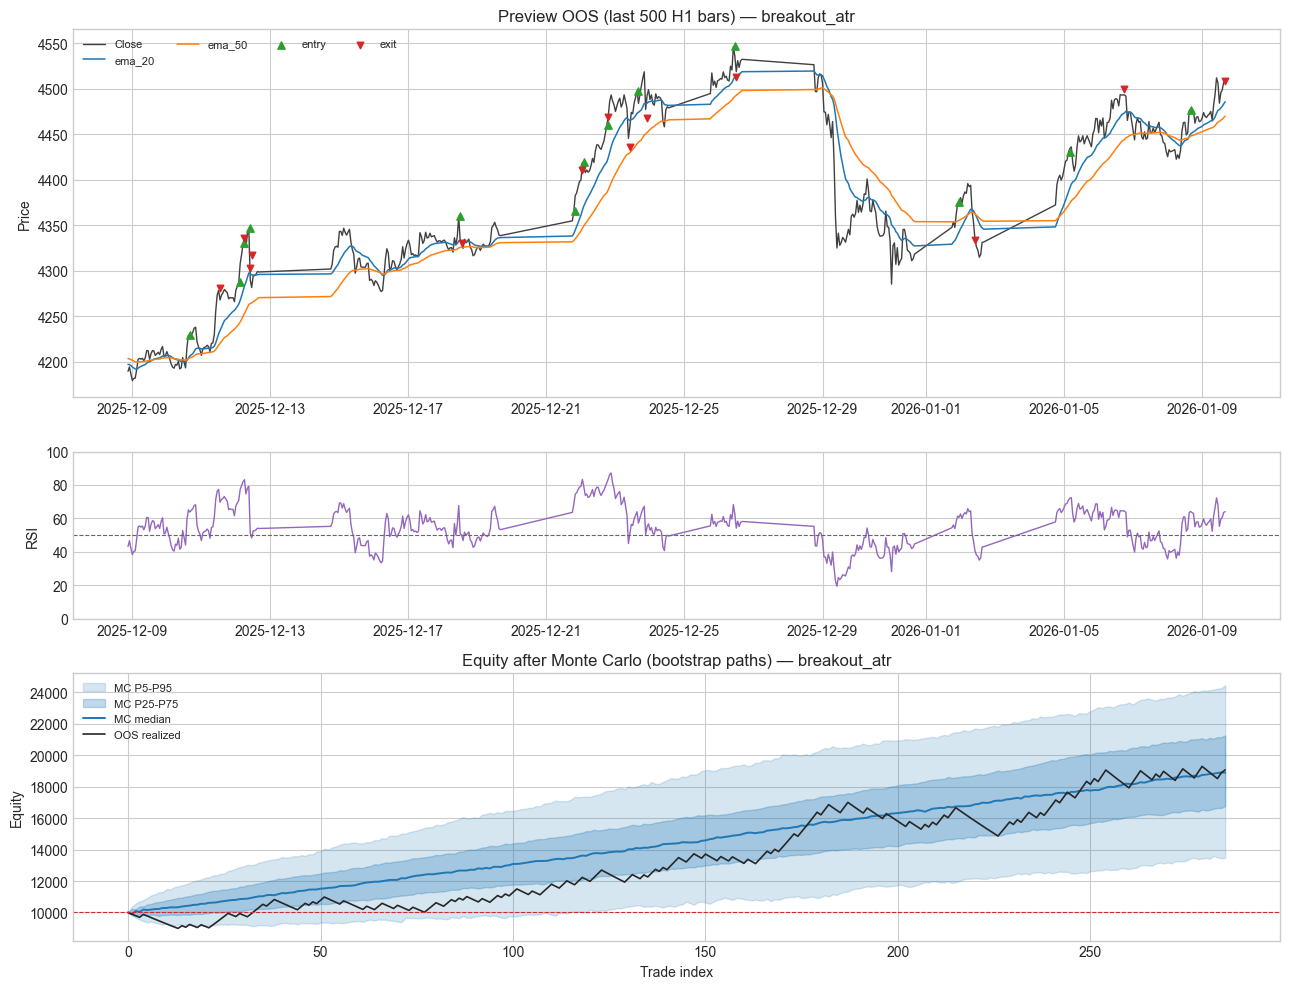

Preview selesai — breakout_atr. Lanjut cell export untuk menulis spec MQL5.



### XAUUSD 1H — `ema_rsi_volume`

**Logika (siap MQL5)**

LONG jika EMA_fast > EMA_slow AND RSI > threshold AND Volume > Volume_MA.
Jika data volume mati (hampir semua 0), filter volume diabaikan.
SHORT tidak dipakai.
Exit: SL = sl_atr * ATR, TP = tp_atr * ATR.
Execution: next bar open, sinyal pada candle yang sudah close.

| Item | Nilai |
|---|---|
| EMA fast / slow | 20 / 50 |
| RSI period / threshold | 14 / 50 |
| SL / TP | 2.0 ATR / 4.0 ATR |
| Volume filter | OFF (data volume mati) |
| Execution | next bar open, 1 posisi |
| OOS return | 183.6% |
| OOS Sharpe (daily) | 1.88 |
| OOS max DD | -15.4% |
| Trades OOS | 448 |
| MC median equity | 28,456 |
| MC 5th pct equity | 19,016 |
| MC P(loss) | 0.06% |
| MC 95% worst DD | -31.2% |
| Risk backtest | 1.00% / trade |
| **Risk disarankan live** | **0.80% / trade** (skala agar 95% DD ~ 25%) |
| Hard stop DD | 31.2% |


Neighbour paling stabil di OOS (perturbasi, bukan peak IS): EMA 20/50  return=183.6%  Sharpe=1.88  DD=-15.4%


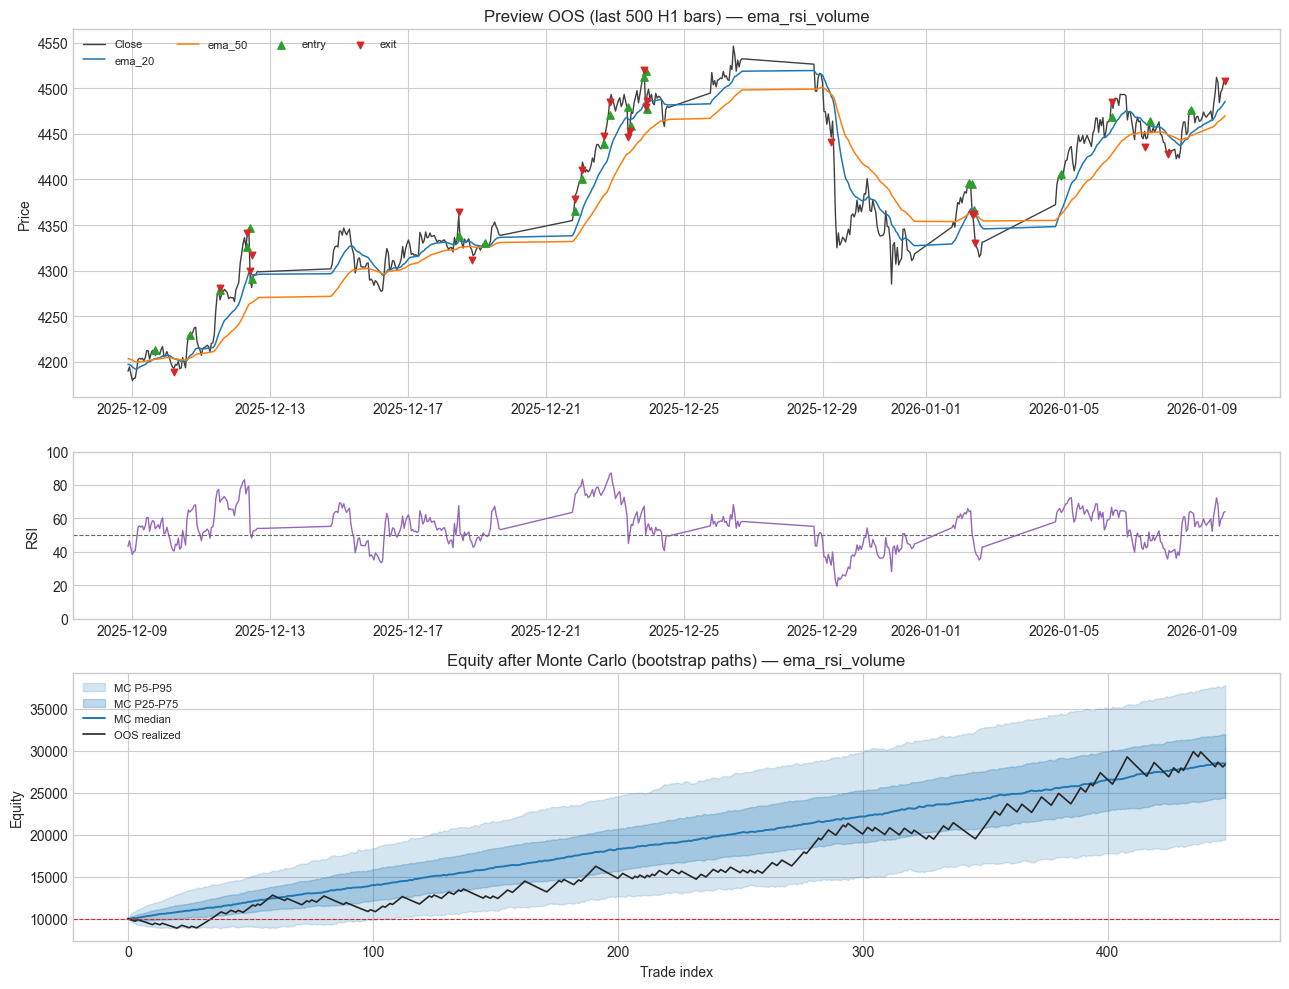

Preview selesai — ema_rsi_volume. Lanjut cell export untuk menulis spec MQL5.



### XAUUSD 1H — `momentum_squeeze_by_kimi`

**Logika (siap MQL5)**

Momentum Squeeze Breakout (by Kimi).
1. Regime       : Close vs EMA200 + EMA_fast vs EMA_slow (arah tren).
2. Volatility   : ADX > adx_th AND ADX rising (adx_14 > adx_14.shift(adx_rise)).
3. Compression  : Donchian width / ATR < rolling median 100 (squeeze).
4. Trigger      : Close menembus Donchian High/Low setelah squeeze (shift 1).
5. Momentum     : RSI > rsi_long (52) Long / RSI < rsi_short (48) Short.
6. Exit         : SL = 2.0 * ATR, TP = 4.0 * ATR.
Execution       : next bar open, sinyal pada candle yang sudah close.

| Item | Nilai |
|---|---|
| EMA fast / slow | 20 / 50 |
| RSI period / threshold | 14 / 50 |
| SL / TP | 2.0 ATR / 4.0 ATR |
| Volume filter | OFF (data volume mati) |
| Execution | next bar open, 1 posisi |
| OOS return | 25.3% |
| OOS Sharpe (daily) | 0.87 |
| OOS max DD | -11.5% |
| Trades OOS | 128 |
| MC median equity | 12,522 |
| MC 5th pct equity | 9,603 |
| MC P(loss) | 7.65% |
| MC 95% worst DD | -20.8% |
| Risk backtest | 1.00% / trade |
| **Risk disarankan live** | **1.00% / trade** (skala agar 95% DD ~ 25%) |
| Hard stop DD | 20.8% |


Neighbour paling stabil di OOS (perturbasi, bukan peak IS): EMA 22/52  return=27.9%  Sharpe=0.95  DD=-10.6%


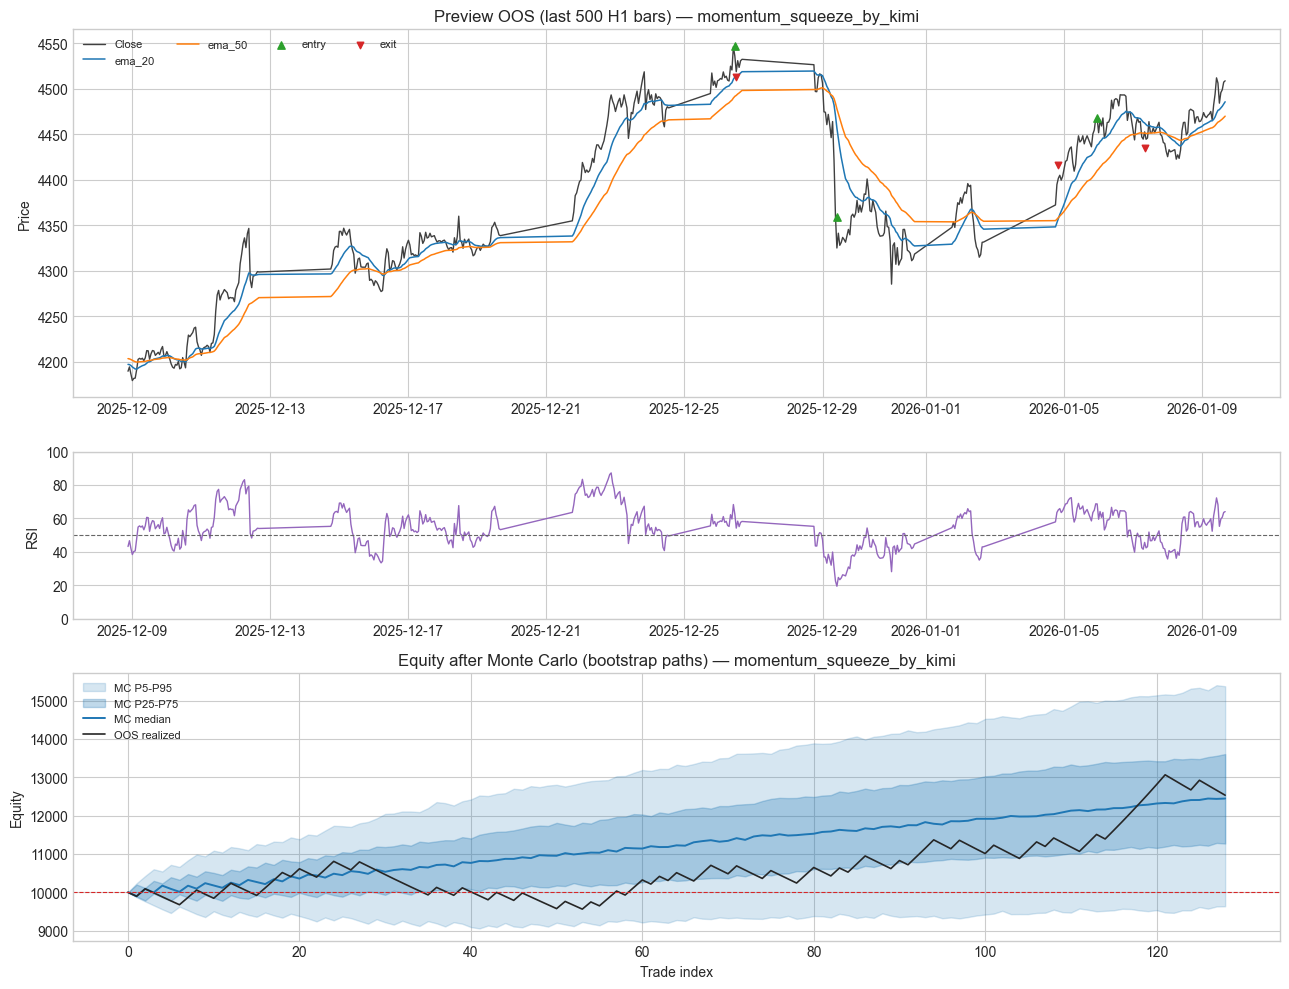

Preview selesai — momentum_squeeze_by_kimi. Lanjut cell export untuk menulis spec MQL5.



### XAUUSD 1H — `trend_breakout_by_gemini`

**Logika (siap MQL5)**

Trend Momentum Donchian Breakout (by Gemini).
1. Macro Regime   : Close > EMA200 (Long) / Close < EMA200 (Short).
2. Trend Alignment: EMA_fast > EMA_slow (Long) / EMA_fast < EMA_slow (Short).
3. Volatility/ADX : ADX > adx_th (20) — skip ranging / choppy market.
4. Momentum RSI   : RSI > rsi_th (50) Long / RSI < (100 - rsi_th) Short.
5. Trigger        : Donchian lookback High/Low breakout (shift 1, no look-ahead).
6. Exit           : SL = 2.0 * ATR, TP = 4.0 * ATR (1:2 R:R).
Execution         : next bar open, sinyal pada candle yang sudah close.

| Item | Nilai |
|---|---|
| EMA fast / slow | 20 / 50 |
| RSI period / threshold | 14 / 50 |
| SL / TP | 2.0 ATR / 4.0 ATR |
| Volume filter | OFF (data volume mati) |
| Execution | next bar open, 1 posisi |
| OOS return | 86.7% |
| OOS Sharpe (daily) | 1.58 |
| OOS max DD | -10.7% |
| Trades OOS | 273 |
| MC median equity | 18,627 |
| MC 5th pct equity | 13,542 |
| MC P(loss) | 0.25% |
| MC 95% worst DD | -21.8% |
| Risk backtest | 1.00% / trade |
| **Risk disarankan live** | **1.00% / trade** (skala agar 95% DD ~ 25%) |
| Hard stop DD | 21.8% |


Neighbour paling stabil di OOS (perturbasi, bukan peak IS): EMA 18/48  return=90.6%  Sharpe=1.63  DD=-10.7%


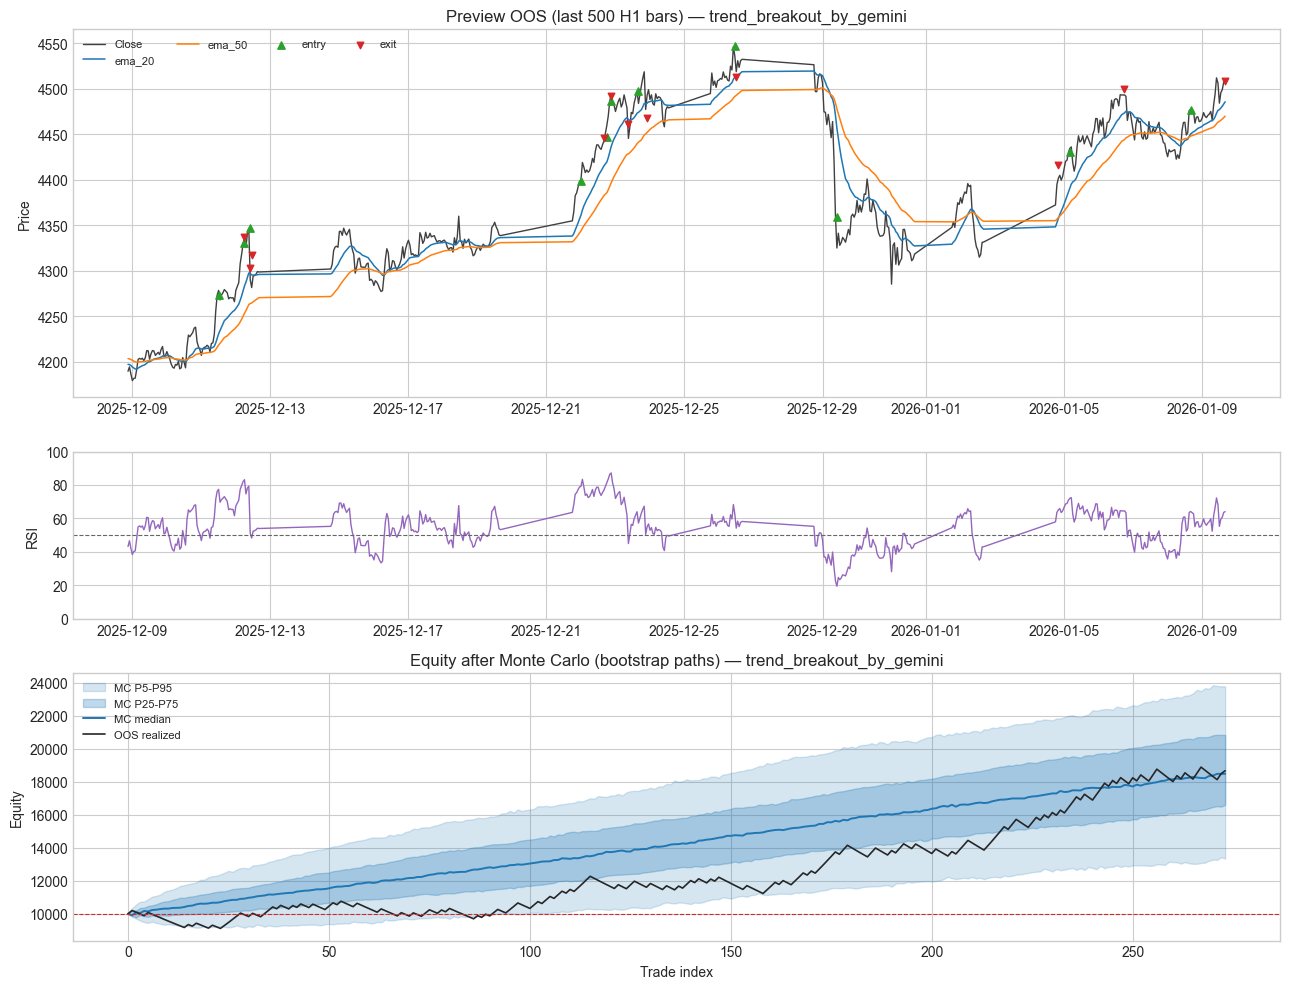

Preview selesai — trend_breakout_by_gemini. Lanjut cell export untuk menulis spec MQL5.



### XAUUSD 1H — `trend_pullback_by_claude`

**Logika (siap MQL5)**

Trend-pullback momentum (by Claude).
Regime : Close > EMA200 AND EMA200 naik (vs 5 bar lalu) -> hanya ikut uptrend besar.
Kualitas: ADX > adx_min (trend nyata, bukan ranging) AND EMA_fast > EMA_slow.
Trigger : pullback -- Low menyentuh/di bawah EMA_fast dalam pull_bars bar terakhir,
          lalu Close kembali di atas EMA_fast dan RSI > 50 (momentum resume).
SHORT tidak dipakai.
Exit    : SL = sl_atr * ATR (2.0), TP = tp_atr * ATR (4.0) -> minimal 2R.
Execution: next bar open, sinyal pada candle yang sudah close.

| Item | Nilai |
|---|---|
| EMA fast / slow | 20 / 50 |
| RSI period / threshold | 14 / 50 |
| SL / TP | 2.0 ATR / 4.0 ATR |
| Volume filter | OFF (data volume mati) |
| Execution | next bar open, 1 posisi |
| OOS return | 76.5% |
| OOS Sharpe (daily) | 1.57 |
| OOS max DD | -7.4% |
| Trades OOS | 192 |
| MC median equity | 17,632 |
| MC 5th pct equity | 12,865 |
| MC P(loss) | 0.29% |
| MC 95% worst DD | -21.2% |
| Risk backtest | 1.00% / trade |
| **Risk disarankan live** | **1.00% / trade** (skala agar 95% DD ~ 25%) |
| Hard stop DD | 21.2% |


Neighbour paling stabil di OOS (perturbasi, bukan peak IS): EMA 22/52  return=80.6%  Sharpe=1.67  DD=-7.1%


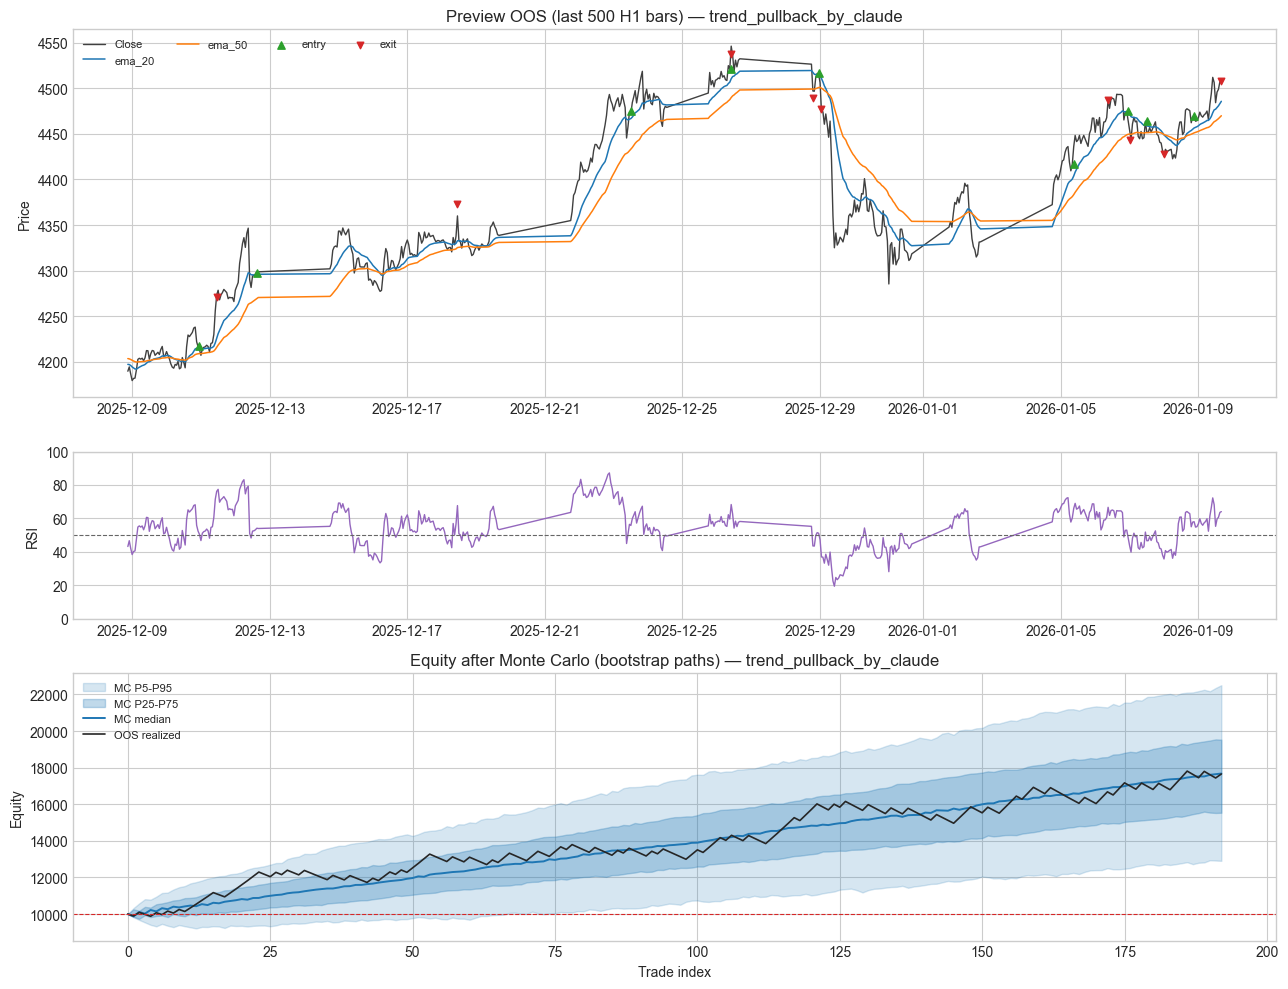

Preview selesai — trend_pullback_by_claude. Lanjut cell export untuk menulis spec MQL5.


In [10]:
from IPython.display import Markdown

if not DEEP_QUEUE:
    print("Skip preview (screening only). Set MULTI_DEEP=True untuk menjalankan.")
else:
    for CURRENT_STRATEGY in DEEP_QUEUE:
        pack = PIPELINE[CURRENT_STRATEGY]
        bt_oos = pack["bt_oos"]
        bt_full = pack["bt_full"]
        mc = pack.get("mc", {})
        perturb_df = pack.get("perturb_df", pd.DataFrame())

        preview_bt = bt_oos if len(getattr(bt_oos, "trades", [])) else bt_full
        boot = mc.get("bootstrap", {}) if isinstance(mc, dict) else {}
        shuffle = mc.get("shuffle", {}) if isinstance(mc, dict) else {}
        p = dict(PARAMS)
        vol_on = bool(p.get("use_volume_filter", True)) and VOLUME_USABLE
        logic = STRATEGY_SPECS.get(CURRENT_STRATEGY, "")

        worst_dd = abs(float(boot.get("p95_worst_dd", preview_bt.metrics.get("max_drawdown", 0.3))))
        target_live_dd = 0.25
        risk_scale = min(1.0, target_live_dd / max(worst_dd, 1e-6))
        live_risk = RISK_PCT * risk_scale
        hard_halt = max(worst_dd, abs(float(preview_bt.metrics.get("max_drawdown", 0.0))))

        robust_pick = None
        if len(perturb_df):
            cand = perturb_df.copy()
            cand = cand[cand["oos_return"] > 0]
            if len(cand):
                robust_pick = cand.sort_values("oos_sharpe", ascending=False).iloc[0]

        md = f"""
### {SYMBOL} {TIMEFRAME} — `{CURRENT_STRATEGY}`

**Logika (siap MQL5)**

{logic}

| Item | Nilai |
|---|---|
| EMA fast / slow | {int(p['ema_fast'])} / {int(p['ema_slow'])} |
| RSI period / threshold | {int(p['rsi_period'])} / {p['rsi_threshold']} |
| SL / TP | {p['atr_sl']} ATR / {p['atr_tp']} ATR |
| Volume filter | {'ON' if vol_on else 'OFF (data volume mati)'} |
| Execution | next bar open, 1 posisi |
| OOS return | {preview_bt.metrics['total_return']:.1%} |
| OOS Sharpe (daily) | {preview_bt.metrics['sharpe']:.2f} |
| OOS max DD | {preview_bt.metrics['max_drawdown']:.1%} |
| Trades OOS | {int(preview_bt.metrics['trades'])} |
| MC median equity | {boot.get('median_final', float('nan')):,.0f} |
| MC 5th pct equity | {boot.get('p5_final', float('nan')):,.0f} |
| MC P(loss) | {boot.get('prob_loss', float('nan')):.2%} |
| MC 95% worst DD | {boot.get('p95_worst_dd', float('nan')):.1%} |
| Risk backtest | {RISK_PCT:.2%} / trade |
| **Risk disarankan live** | **{live_risk:.2%} / trade** (skala agar 95% DD ~ {target_live_dd:.0%}) |
| Hard stop DD | {hard_halt:.1%} |
"""
        display(Markdown(md))

        if robust_pick is not None:
            print(
                "Neighbour paling stabil di OOS (perturbasi, bukan peak IS): "
                f"EMA {robust_pick['ema']}  return={robust_pick['oos_return']:.1%}  "
                f"Sharpe={robust_pick['oos_sharpe']:.2f}  DD={robust_pick['oos_dd']:.1%}"
            )

        oos_sig = apply_strategy(slice_df(df_ind, start=OOS_START), CURRENT_STRATEGY, PARAMS)
        tail_n = min(500, len(oos_sig))
        tail = oos_sig.tail(tail_n).copy()
        fast_col = f"ema_{int(p['ema_fast'])}"
        slow_col = f"ema_{int(p['ema_slow'])}"
        entries = preview_bt.trades.copy() if len(preview_bt.trades) else pd.DataFrame()
        if len(entries):
            entries["entry_time"] = pd.to_datetime(entries["entry_time"])
            t0, t1 = tail["Datetime"].min(), tail["Datetime"].max()
            entries_tail = entries[(entries["entry_time"] >= t0) & (entries["entry_time"] <= t1)]
        else:
            entries_tail = entries

        fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False, gridspec_kw={"height_ratios": [2.2, 1.0, 1.6]})

        ax = axes[0]
        ax.plot(tail["Datetime"], tail["Close"], color="0.25", lw=1.0, label="Close")
        if fast_col in tail.columns:
            ax.plot(tail["Datetime"], tail[fast_col], color="C0", lw=1.1, label=fast_col)
        if slow_col in tail.columns:
            ax.plot(tail["Datetime"], tail[slow_col], color="C1", lw=1.1, label=slow_col)
        if len(entries_tail):
            ax.scatter(entries_tail["entry_time"], entries_tail["entry"], marker="^", color="C2", s=28, zorder=3, label="entry")
            exits = entries_tail.copy()
            ax.scatter(pd.to_datetime(exits["exit_time"]), exits["exit"], marker="v", color="C3", s=22, zorder=3, label="exit")
        ax.set_title(f"Preview OOS (last {tail_n} H1 bars) — {CURRENT_STRATEGY}")
        ax.set_ylabel("Price")
        ax.legend(loc="upper left", ncol=4, fontsize=8)

        axr = axes[1]
        axr.plot(tail["Datetime"], tail["rsi_14"], color="C4", lw=1.0)
        axr.axhline(p["rsi_threshold"], color="0.4", ls="--", lw=0.8)
        axr.set_ylabel("RSI")
        axr.set_ylim(0, 100)

        axm = axes[2]
        if len(preview_bt.trades):
            pnls = preview_bt.trades["pnl"].to_numpy(float)
            n = len(pnls)
            n_plot = min(800, N_MC_SIMS)
            rng = np.random.default_rng(MC_SEED)
            idx = rng.integers(0, n, size=(n_plot, n))
            paths = INITIAL_EQUITY + np.cumsum(pnls[idx], axis=1)
            paths = np.concatenate([np.full((n_plot, 1), INITIAL_EQUITY), paths], axis=1)
            x = np.arange(paths.shape[1])
            axm.fill_between(x, np.percentile(paths, 5, axis=0), np.percentile(paths, 95, axis=0), color="C0", alpha=0.18, label="MC P5-P95")
            axm.fill_between(x, np.percentile(paths, 25, axis=0), np.percentile(paths, 75, axis=0), color="C0", alpha=0.28, label="MC P25-P75")
            axm.plot(x, np.percentile(paths, 50, axis=0), color="C0", lw=1.4, label="MC median")
            realized = np.concatenate([[INITIAL_EQUITY], INITIAL_EQUITY + np.cumsum(pnls)])
            axm.plot(np.arange(len(realized)), realized, color="0.15", lw=1.2, label="OOS realized")
            axm.axhline(INITIAL_EQUITY, color="C3", ls="--", lw=0.8)
            axm.set_xlabel("Trade index")
            axm.set_ylabel("Equity")
            axm.set_title(f"Equity after Monte Carlo (bootstrap paths) — {CURRENT_STRATEGY}")
            axm.legend(loc="upper left", fontsize=8)
        else:
            axm.text(0.5, 0.5, "No trades to preview", ha="center", va="center")
            axm.set_axis_off()

        plt.tight_layout()
        plt.show()

        print(f"Preview selesai — {CURRENT_STRATEGY}. Lanjut cell export untuk menulis spec MQL5.")


## 11. Final evaluation + export spec MQL5

Scorecard `FAIL / FRAGILE / ACCEPTABLE / ROBUST`. File `.md` dan `.txt` di `exports/` untuk acuan Expert Advisor.


In [11]:
def fmt_pct(x: float) -> str:
    return f"{x:.2%}"


def fmt_num(x: float) -> str:
    return f"{x:,.2f}"


def build_mql5_spec() -> str:
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    p = PARAMS
    vol_note = "applied" if (VOLUME_USABLE and p.get("use_volume_filter", True)) else "DISABLED (volume data dead / unused)"
    logic = STRATEGY_SPECS.get(CURRENT_STRATEGY, "")
    boot = mc.get("bootstrap", {})
    rec_risk = RISK_PCT
    hard_dd = abs(min(bt_oos.metrics["max_drawdown"], boot.get("p95_worst_dd", bt_oos.metrics["max_drawdown"])))
    implement = "YES" if STATUS in {"ROBUST", "ACCEPTABLE"} else "NO"

    def gate(v: bool) -> str:
        return "PASS" if v else "FAIL"

    return f"""# MQL5 Strategy Spec

## 1. Identity
- Strategy name     : {CURRENT_STRATEGY}
- Version           : 1.0.0
- Status            : {STATUS}
- Generated at      : {now}
- Source notebook   : {SOURCE_NOTEBOOK}
- Plugin function   : {CURRENT_STRATEGY}

## 2. Market & execution
- Symbol            : {SYMBOL}
- Timeframe         : PERIOD_H1
- Chart price       : Close of completed candle
- Entry timing      : next candle open after signal (no look-ahead)
- Magic number      : 2026081701
- Comment           : ATB_{CURRENT_STRATEGY}

## 3. Input parameters (MQL5 `input`)
input int    InpEmaFast        = {int(p['ema_fast'])};
input int    InpEmaSlow        = {int(p['ema_slow'])};
input int    InpEmaTrend       = {int(p.get('ema_trend', 200))};
input int    InpLookback       = {int(p.get('lookback', 20))};
input int    InpRsiPeriod      = {int(p['rsi_period'])};
input double InpRsiThreshold   = {float(p.get('rsi_th', p['rsi_threshold']))};
input double InpRsiLong        = {float(p.get('rsi_long', 52.0))};
input double InpRsiShort       = {float(p.get('rsi_short', 48.0))};
input double InpAdxMin         = {float(p.get('adx_th', p.get('adx_min', 20.0)))};
input int    InpAdxRise        = {int(p.get('adx_rise', 3))};
input int    InpVolumeMa       = {int(p['volume_ma'])};
input int    InpAtrPeriod      = {int(p['atr_period'])};
input double InpSlAtr          = {float(p['atr_sl'])};
input double InpTpAtr          = {float(p['atr_tp'])};
input bool   InpAllowShort     = {'true' if p.get('allow_short', False) else 'false'};
input double InpRiskPercent    = {RISK_PCT * 100:.2f};
input ulong  InpMagic          = 2026081701;

## 4. Indicators
- EMA fast   : iMA(_Symbol, PERIOD_H1, InpEmaFast, 0, MODE_EMA, PRICE_CLOSE)
- EMA slow   : iMA(_Symbol, PERIOD_H1, InpEmaSlow, 0, MODE_EMA, PRICE_CLOSE)
- EMA trend  : iMA(_Symbol, PERIOD_H1, InpEmaTrend, 0, MODE_EMA, PRICE_CLOSE)
- Donchian   : Highest(High, InpLookback) / Lowest(Low, InpLookback) on bar [1]
- RSI        : iRSI(_Symbol, PERIOD_H1, InpRsiPeriod, PRICE_CLOSE)
- ADX        : iADX(_Symbol, PERIOD_H1, 14)  (filter ADX > InpAdxMin)
- ATR        : iATR(_Symbol, PERIOD_H1, InpAtrPeriod)
- Volume MA  : SMA(tick_volume atau real_volume, InpVolumeMa)  [{vol_note}]

Pakai nilai bar [1] (candle yang sudah close). Jangan pakai bar [0] untuk keputusan entry.

## 5. Entry logic
Plugin docstring (source of truth for EA rules):
{logic}

Sinyal dihitung pada bar [1] (candle close). Order dikirim pada open bar [0] (next-bar execution).
Max 1 posisi. Jangan entry jika sudah ada posisi dengan magic yang sama.

## 6. Exit logic
- Long  SL : entry_price - InpSlAtr * ATR[1]
- Long  TP : entry_price + InpTpAtr * ATR[1]
- Short SL : entry_price + InpSlAtr * ATR[1]
- Short TP : entry_price - InpTpAtr * ATR[1]
- SL/TP dipasang saat OrderSend / PositionOpen
- Tidak ada trailing pada versi ini
- Exit tambahan: tidak ada (hanya SL/TP)
- Jika SL dan TP tersentuh di bar yang sama: anggap SL (konservatif, sama dengan backtest)

## 7. Risk & position sizing
- Risiko per trade     : InpRiskPercent % dari equity
- Lot                  : risk_money / (SL_distance_in_price * contract_size)
- Contract size        : {CONTRACT_SIZE}
- Max positions        : {MAX_POSITIONS}
- Max daily loss       : n/a (set di EA jika perlu)
- Max drawdown halt    : {hard_dd:.2%}

## 8. Order / filling notes
- Filling              : SYMBOL_FILLING_FOK atau IOC sesuai broker
- Deviation / slippage : {SLIPPAGE:.4%} plus spread {SPREAD} (backtest)
- Spread filter        : tolak entry jika spread > ATR[1] * 0.15
- Trading hours        : 24h XAU (broker server)
- Commission           : {COMMISSION_PER_LOT:.2f} USD round-turn per 1.00 lot
- Fee %                : {FEE:.4%} notional per side

## 9. Backtest summary
- Period               : {h1_report['start']} → {h1_report['end']}
- In-sample            : ≤ {IN_SAMPLE_END}
- Out-of-sample        : ≥ {OOS_START}
- Initial capital      : {fmt_num(INITIAL_EQUITY)}
- Final capital IS     : {fmt_num(bt_is.metrics['final_equity'])}
- Final capital OOS    : {fmt_num(bt_oos.metrics['final_equity'])}
- Total return IS      : {fmt_pct(bt_is.metrics['total_return'])}
- Total return OOS     : {fmt_pct(bt_oos.metrics['total_return'])}
- CAGR IS / OOS        : {fmt_pct(bt_is.metrics['cagr'])} / {fmt_pct(bt_oos.metrics['cagr'])}
- Sharpe IS / OOS      : {bt_is.metrics['sharpe']:.3f} / {bt_oos.metrics['sharpe']:.3f}
- Sortino OOS          : {bt_oos.metrics['sortino']:.3f}
- Max drawdown IS/OOS  : {fmt_pct(bt_is.metrics['max_drawdown'])} / {fmt_pct(bt_oos.metrics['max_drawdown'])}
- Win rate OOS         : {fmt_pct(bt_oos.metrics['win_rate'])}
- Profit factor OOS    : {bt_oos.metrics['profit_factor']:.3f}
- Trades IS / OOS      : {bt_is.metrics['trades']} / {bt_oos.metrics['trades']}
- Average win / loss   : {fmt_num(bt_oos.metrics['average_win'])} / {fmt_num(bt_oos.metrics['average_loss'])}
- Longest losing streak: {bt_oos.metrics['longest_losing_streak']}
- Volume filter        : {vol_note}

## 10. Risk assessment
- Parameter stable     : {'YES' if PARAM_STABLE and PERTURB_STABLE else 'NO'}
- Cost stress 2x fee   : {'YES' if COST_PASS else 'NO'}
- Monte Carlo sims     : {N_MC_SIMS}
- Median final equity  : {fmt_num(boot.get('median_final', float('nan')))}
- 5th percentile equity: {fmt_num(boot.get('p5_final', float('nan')))}
- Probability of loss  : {fmt_pct(boot.get('prob_loss', float('nan')))}
- Median max DD        : {fmt_pct(boot.get('median_max_dd', float('nan')))}
- 95% worst DD         : {fmt_pct(boot.get('p95_worst_dd', float('nan')))}
- Probability DD > 30% : {fmt_pct(boot.get('prob_dd_gt_30', float('nan')))}
- Recommended live risk: {rec_risk:.2%} per trade
- Hard stop live DD    : {hard_dd:.2%}

## 11. Decision gate
- In-sample            : {gate(gates['in_sample'])}
- Out-of-sample        : {gate(gates['out_of_sample'])}
- Walk-forward         : {gate(gates['walk_forward'])}
- Parameter stability  : {gate(gates['parameter_stability'])}
- Cost stress          : {gate(gates['cost_stress'])}
- Monte Carlo          : {gate(gates['monte_carlo'])}
- FINAL STATUS         : {STATUS}
- Implement to MQL5    : {implement}

## 12. MQL5 checklist
- [ ] Copy input parameters exactly
- [ ] Indicators on closed bar [1]
- [ ] Next-bar entry
- [ ] SL/TP in price from ATR
- [ ] One position per magic
- [ ] Risk % lot sizing
- [ ] Spread filter
- [ ] Journal log setiap entry/exit (alasan aturan)
- [ ] Strategy Tester: every tick based on real ticks jika tersedia
- [ ] Paper test sebelum live
"""


def export_mql5_spec(text: str, status: str) -> tuple[str, str]:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d")
    prefix = "" if status in {"ROBUST", "ACCEPTABLE"} else "REJECTED_"
    stem = f"{prefix}{SYMBOL}_{TIMEFRAME}_{CURRENT_STRATEGY}_{stamp}"
    md_path = EXPORT_DIR / f"{stem}.md"
    txt_path = EXPORT_DIR / f"{stem}.txt"
    md_path.write_text(text, encoding="utf-8")
    txt_path.write_text(text, encoding="utf-8")
    return str(md_path), str(txt_path)

if not DEEP_QUEUE:
    print("Skip export (screening only). Set MULTI_DEEP=True untuk menjalankan.")
else:
    compare_status_rows = []
    for CURRENT_STRATEGY in DEEP_QUEUE:
        pack = PIPELINE[CURRENT_STRATEGY]
        bt_is = pack["bt_is"]
        bt_oos = pack["bt_oos"]
        WF_PASS = pack.get("WF_PASS", False)
        PARAM_STABLE = pack.get("PARAM_STABLE", False)
        PERTURB_STABLE = pack.get("PERTURB_STABLE", False)
        COST_PASS = pack.get("COST_PASS", False)
        MC_PASS = pack.get("MC_PASS", False)
        mc = pack.get("mc", {})

        IS_PASS = bt_is.metrics["sharpe"] > 1.0 and bt_is.metrics["trades"] >= 30
        OOS_PASS = bt_oos.metrics["sharpe"] > 0.8 and bt_oos.metrics["total_return"] > 0 and bt_oos.metrics["trades"] >= 10

        gates = {
            "in_sample": IS_PASS,
            "out_of_sample": OOS_PASS,
            "walk_forward": WF_PASS,
            "parameter_stability": PARAM_STABLE and PERTURB_STABLE,
            "cost_stress": COST_PASS,
            "monte_carlo": MC_PASS,
        }

        n_pass = sum(bool(v) for v in gates.values())
        if not OOS_PASS or bt_oos.metrics["total_return"] <= 0:
            STATUS = "FAIL"
        elif n_pass == 6:
            STATUS = "ROBUST"
        elif n_pass >= 4 and OOS_PASS:
            STATUS = "ACCEPTABLE"
        else:
            STATUS = "FRAGILE"

        pack["gates"] = gates
        pack["STATUS"] = STATUS
        print(f"Decision gate — {CURRENT_STRATEGY}")
        for k, v in gates.items():
            print(f"  {'PASS' if v else 'FAIL':4s}  {k}")
        print(f"FINAL STATUS = {STATUS}")
        print(f"Implement to MQL5 = {'YES' if STATUS in {'ROBUST', 'ACCEPTABLE'} else 'NO'}")

        spec_text = build_mql5_spec()
        md_file, txt_file = export_mql5_spec(spec_text, STATUS)
        print("Exported:")
        print(" ", md_file)
        print(" ", txt_file)
        compare_status_rows.append(
            {
                "strategy": CURRENT_STRATEGY,
                "status": STATUS,
                "oos_sharpe": bt_oos.metrics["sharpe"],
                "oos_return": bt_oos.metrics["total_return"],
                "implement": STATUS in {"ROBUST", "ACCEPTABLE"},
            }
        )

    if len(compare_status_rows) > 1:
        print("\n=== Multi strategy decision ===")
        display(pd.DataFrame(compare_status_rows).sort_values("oos_sharpe", ascending=False))


Decision gate — breakout_atr
  FAIL  in_sample
  PASS  out_of_sample
  FAIL  walk_forward
  PASS  parameter_stability
  PASS  cost_stress
  PASS  monte_carlo
FINAL STATUS = ACCEPTABLE
Implement to MQL5 = YES
Exported:
  exports\XAUUSD_1H_breakout_atr_20260817.md
  exports\XAUUSD_1H_breakout_atr_20260817.txt
Decision gate — ema_rsi_volume
  FAIL  in_sample
  PASS  out_of_sample
  PASS  walk_forward
  PASS  parameter_stability
  PASS  cost_stress
  PASS  monte_carlo
FINAL STATUS = ACCEPTABLE
Implement to MQL5 = YES
Exported:
  exports\XAUUSD_1H_ema_rsi_volume_20260817.md
  exports\XAUUSD_1H_ema_rsi_volume_20260817.txt
Decision gate — momentum_squeeze_by_kimi
  FAIL  in_sample
  PASS  out_of_sample
  PASS  walk_forward
  FAIL  parameter_stability
  PASS  cost_stress
  PASS  monte_carlo
FINAL STATUS = ACCEPTABLE
Implement to MQL5 = YES
Exported:
  exports\XAUUSD_1H_momentum_squeeze_by_kimi_20260817.md
  exports\XAUUSD_1H_momentum_squeeze_by_kimi_20260817.txt
Decision gate — trend_breakout_

,strategy,status,oos_sharpe,oos_return,implement
1,ema_rsi_volume,ACCEPTABLE,1.877281,1.835590,True
3,trend_breakout_by_gemini,ACCEPTABLE,1.576912,0.867261,True
4,trend_pullback_by_claude,ACCEPTABLE,1.570072,0.765405,True
0,breakout_atr,ACCEPTABLE,1.554739,0.906510,True
2,momentum_squeeze_by_kimi,ACCEPTABLE,0.868100,0.253320,True
